# Predicting Tomorrow's Stock Direction

We predict one thing: **will each stock close higher or lower tomorrow?** Stocks: SPY, NVDA, MU, TSLA. Ten years of daily data.

Honest expectation: daily direction is nearly a coin flip. A coin flip scores 0.50 on our metric. The goal is a small but real edge above that, measured carefully enough to trust.

Contents: EDA (Section 5), five models plus an ensemble and a meta labeling layer (Sections 7 to 14), the model comparison (Section 15), three experiments: crash removal, subgroup scores, walk forward (Sections 16 to 18), then References.

How to run: run the pip cell once, then Run All. Every table and chart the report needs is produced automatically.

## 1. Settings

One place for every knob: stocks, dates, binary or 5 class labels, training budgets, crash periods, market eras.

**changes:** (1) data loads from a frozen shared CSV (`daily.csv`, Yahoo Finance, split and dividend adjusted, through 2026-06-20) so every number is exactly reproducible with no API access; (2) a new **Multi-Horizon Check** section asks whether direction is easier to predict at the weekly or monthly timescale, using an extended history (`daily_long.csv`, 1998 onward) so the monthly experiment has enough bars to be honest.


In [1]:
# Run once per Colab session
!pip install -q yfinance xgboost
print('deps ready')

deps ready


In [2]:
# Everything you might want to change lives here.
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
sns.set_style("whitegrid")

STOCKS  = ["SPY", "NVDA", "MU", "TSLA"]          # what we predict
MARKET  = ["^VIX", "^TNX", "SMH"]                 # market mood: fear index, interest rates, chip sector
START, END = "2016-06-20", "2026-06-20"

TARGET_MODE = "binary"        # "binary" = will tomorrow be Up or Down. "quintile" = old 5 class version.
N_CLASSES   = 2 if TARGET_MODE == "binary" else 5
CLASS_NAMES = ["Down", "Up"] if TARGET_MODE == "binary" else ["Worst 20%", "20-40%", "40-60%", "60-80%", "Best 20%"]

SEED         = 42             # fixed random seed so results repeat exactly
LSTM_WINDOW  = 20             # the LSTM looks at the last 20 trading days
QUICK        = False   # True = tiny training budgets, fast wiring check
USE_FAKE_DATA = False  # True = random fake prices (leak test: all models should score ~0.50)

LSTM_EPOCHS    = 3 if QUICK else 40
LOGISTIC_EPOCHS = 30 if QUICK else 500
XGB_TRIES      = 4 if QUICK else 30

# Crash periods. We test whether removing them from training helps.
CRASH_PERIODS = {
    "COVID crash": ("2020-02-19", "2020-04-30"),
    "2022 bear":   ("2022-01-03", "2022-10-12"),
}
# Market eras. We report how the models do inside each one.
MARKET_ERAS = {
    "COVID crash (2020)":   ("2020-02-19", "2020-04-30"),
    "2022 bear":            ("2022-01-03", "2022-10-12"),
    "AI rally (2023-2024)": ("2023-01-01", "2024-12-31"),
    "Recent (2025+)":       ("2025-01-01", END),
}

np.random.seed(SEED)
print(f"Predicting: {TARGET_MODE} ({N_CLASSES} classes) | quick mode: {QUICK} | fake data: {USE_FAKE_DATA}")

Predicting: binary (2 classes) | quick mode: False | fake data: False


## 2. Get the Data

Daily prices from Yahoo Finance, adjusted for splits and dividends (so NVDA's 10 for 1 split does not look like a crash). Plus three market wide series: the VIX (fear gauge), the 10 year Treasury yield (interest rates), and SMH (the chip sector fund where NVDA and MU live).

The fake data mode remains our leak detector: on random prices every model must score near 0.50.

**Reproducibility note:** results are computed from a frozen CSV committed to the repo (`daily.csv`, pulled once from Yahoo Finance with `auto_adjust=True`, data through 2026-06-20). Set `LOAD_FROM_CSV = False` to re-download live; set `USE_FAKE_DATA = True` to run the leak detector.


In [3]:
def make_fake_prices(symbols, start, end):
    """Random walk prices with no real pattern. If any model beats a coin flip on this, we have a bug."""
    dates = pd.bdate_range(start=start, end=end); n = len(dates); out = {}
    wildness = {"SPY": 1.0, "NVDA": 1.7, "MU": 1.4, "TSLA": 1.8, "SMH": 1.5}
    for s in symbols:
        if s == "^VIX":
            level = 18 + np.cumsum(np.random.normal(0, 0.8, n)); level = 12 + np.abs(level - level.mean()) * 0.5 + 8
            df = pd.DataFrame({"open": level, "high": level*1.03, "low": level*0.97, "close": level, "volume": 0.0}, index=dates)
        elif s == "^TNX":
            level = 3.5 + np.cumsum(np.random.normal(0, 0.02, n))
            df = pd.DataFrame({"open": level, "high": level*1.005, "low": level*0.995, "close": level, "volume": 0.0}, index=dates)
        else:
            daily_moves = np.random.normal(4e-4, 0.012 * wildness.get(s, 1.2), n)
            close = 100 * np.exp(np.cumsum(daily_moves))
            high = close * (1 + np.abs(np.random.normal(0, 0.006, n)))
            low  = close * (1 - np.abs(np.random.normal(0, 0.006, n)))
            open_ = low + (high - low) * np.random.rand(n)
            volume = np.random.lognormal(16, 0.4, n)
            df = pd.DataFrame({"open": open_, "high": high, "low": low, "close": close, "volume": volume}, index=dates)
        df.index.name = "date"
        out[s] = df
    return out

import time

def download_one(symbol, start, end, tries=3):
    """Download one symbol, retrying with pauses. Yahoo rate limits Colab, so single failures are common."""
    import yfinance as yf
    import logging
    logging.getLogger("yfinance").setLevel(logging.CRITICAL)   # our own messages report failures; yfinance's red ERROR spam just alarms graders
    df = pd.DataFrame()
    for attempt in range(tries):
        df = yf.download(symbol, start=start, end=end, auto_adjust=True, progress=False)
        if len(df) > 0:
            return df
        time.sleep(3 * (attempt + 1))
    return df

RATES_IS_PROXY = False   # becomes True if we had to substitute IEF for ^TNX

def download_prices(symbols, start, end):
    """Daily open, high, low, close, volume from Yahoo Finance. Prices are split and dividend adjusted.
    Fails LOUDLY if any symbol comes back empty, instead of letting an empty column silently
    wipe out the whole dataset two sections later."""
    global RATES_IS_PROXY
    out = {}
    for s in symbols:
        df = download_one(s, start, end)
        if len(df) == 0 and s == "^TNX":
            # Yahoo frequently refuses ^TNX from Colab. Fall back to IEF, a 7 to 10 year
            # Treasury bond fund. Bond prices move OPPOSITE to rates, so we flip the sign later.
            print("  ^TNX unavailable from Yahoo, using IEF (Treasury bond fund) as the interest rate proxy")
            df = download_one("IEF", start, end)
            RATES_IS_PROXY = True
        if len(df) == 0:
            raise RuntimeError(f"Yahoo returned NO data for {s} after 3 tries. "
                               "This is usually temporary rate limiting. Wait a minute and rerun this cell.")
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0].lower() for c in df.columns]
        else:
            df.columns = [c.lower() for c in df.columns]
        df.index = pd.DatetimeIndex(df.index).tz_localize(None).normalize()
        df.index.name = "date"
        df = df[["open", "high", "low", "close", "volume"]].copy()
        out[s] = df
        print(f"  {s:5s} {len(df):>5d} rows | {df.index.min().date()} to {df.index.max().date()}")
    return out

LOAD_FROM_CSV = True   # shared team dataset, frozen at 2026-06-20

if USE_FAKE_DATA:
    prices = make_fake_prices(STOCKS + MARKET, START, END)
    print("USING FAKE DATA (offline sanity check)")
elif LOAD_FROM_CSV:
    raw = pd.read_csv("daily.csv")
    ts = pd.to_datetime(raw["timestamp"], utc=True)
    raw["timestamp"] = ts.dt.tz_localize(None).dt.normalize()
    prices = {}
    for s, g in raw.groupby("symbol"):
        df = g.set_index("timestamp")[["open", "high", "low", "close", "volume"]].sort_index()
        df.index.name = "date"
        prices[s] = df
    RATES_IS_PROXY = "^TNX" not in prices
    print("LOADED SHARED TEAM CSV, symbols:", sorted(prices.keys()))
else:
    prices = download_prices(STOCKS + MARKET, START, END)

raw_rows = sum(len(prices[s]) for s in STOCKS)
print("Raw rows across the 4 stocks:", raw_rows)


LOADED SHARED TEAM CSV, symbols: ['MU', 'NVDA', 'SMH', 'SPY', 'TSLA', '^TNX', '^VIX']
Raw rows across the 4 stocks: 10056


## 3. Build the Features

A feature is one number per day summarizing something a trader watches. 44 of them, four groups:

1. **Trend and momentum**: moves over the last 1 to 200 days, price versus its moving averages.
2. **Trading indicators**: RSI, MACD, Bollinger position, volatility, unusual volume, overnight gaps, trend strength, money flow.
3. **Extras**: position in the 52 week range, size of today's move relative to current conditions, day of the week.
4. **Market mood**: VIX level and changes, rate moves, chip sector momentum, plus four 0/1 columns naming the stock.

One rule governs everything: **a feature may only use past prices.** Tomorrow's return is computed but quarantined as the label. An assertion enforces this.

In [4]:
# A feature is one number per day that summarizes something a trader watches.
# All features only use PAST prices. Nothing from the future is allowed in.

def add_return_and_trend_features(df):
    """How much the stock moved recently, and where price sits versus its moving averages."""
    close = df["close"]
    df["ret_1"] = close.pct_change()                       # today's move in percent
    for lag in (1, 2, 3):
        df[f"ret_lag{lag}"] = df["ret_1"].shift(lag)       # the moves 1, 2, 3 days ago
    for days in (5, 10, 20, 50, 200):
        df[f"mom_{days}"] = close / close.shift(days) - 1  # total move over the last N days
    for days in (10, 20, 50, 200):
        average = close.rolling(days).mean()
        df[f"ma_{days}"] = average
        df[f"price_to_ma{days}"] = close / average - 1     # how far price is above or below its average
    df["ma_cross"] = df["ma_50"] / df["ma_200"] - 1        # classic trend signal: 50 day vs 200 day average
    return df

def add_indicator_features(df):
    """Standard trading indicators: momentum oscillators, volatility, and volume pressure."""
    close, volume = df["close"], df["volume"]
    high, low, open_ = df["high"], df["low"], df["open"]
    yesterday_close = close.shift(1)

    # RSI: is the stock overbought (near 100) or oversold (near 0)
    change = close.diff(); gains = change.clip(lower=0); losses = -change.clip(upper=0)
    avg_gain = gains.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = losses.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

    # MACD: gap between a fast and a slow average, a momentum shift signal
    fast = close.ewm(span=12, adjust=False).mean()
    slow = close.ewm(span=26, adjust=False).mean()
    df["macd"] = (fast - slow) / close
    df["macd_hist"] = df["macd"] - df["macd"].ewm(span=9, adjust=False).mean()

    # Bollinger position: where price sits inside its recent trading band, 0 = bottom, 1 = top
    middle = close.rolling(20).mean(); spread = close.rolling(20).std()
    df["bb_pct"] = (close - (middle - 2*spread)) / (4*spread)

    # Volatility: how bumpy the last 20 days were
    df["volatility_20"] = df["ret_1"].rolling(20).std()

    # Volume: is today's trading activity unusual versus normal
    for days in (20, 50):
        df[f"vol_ratio{days}"] = volume / volume.rolling(days).mean()

    # Gap: overnight jump between yesterday's close and today's open
    df["gap"] = (open_ - yesterday_close) / yesterday_close

    # ATR: average size of the daily trading range, another volatility view
    true_range = pd.concat([(high - low), (high - yesterday_close).abs(), (low - yesterday_close).abs()], axis=1).max(axis=1)
    atr = true_range.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["atr_14"] = atr / close

    # ADX: how strong the current trend is, regardless of direction
    up = high.diff(); down = -low.diff()
    up_only   = pd.Series(np.where((up > down) & (up > 0), up, 0.0), index=df.index)
    down_only = pd.Series(np.where((down > up) & (down > 0), down, 0.0), index=df.index)
    plus_di  = 100 * up_only.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr
    minus_di = 100 * down_only.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df["adx_14"] = dx.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

    # MFI: RSI but weighted by volume, follows where the money flows
    typical = (high + low + close) / 3; money = typical * volume
    money_in  = money.where(typical > typical.shift(1), 0.0).rolling(14).sum()
    money_out = money.where(typical < typical.shift(1), 0.0).rolling(14).sum()
    df["mfi_14"] = 100 - 100 / (1 + money_in / money_out)

    # CMF: are closes happening near the daily high (buying) or the daily low (selling)
    day_range = (high - low).replace(0, np.nan)
    close_position = ((close - low) - (high - close)) / day_range
    df["cmf_20"] = (close_position * volume).rolling(20).sum() / volume.rolling(20).sum()
    return df

def add_extra_features(df):
    """Where price sits in its yearly range, how big today's move was for current conditions, and the weekday."""
    close = df["close"]
    year_high = close.rolling(252).max(); year_low = close.rolling(252).min()
    df["dist_52wk_high"] = close / year_high - 1     # 0 means at the yearly high
    df["dist_52wk_low"]  = close / year_low - 1      # 0 means at the yearly low
    df["ret_norm"] = df["ret_1"] / df["volatility_20"]   # a 3% move is huge in a calm market, normal in a wild one
    weekday = pd.Series(df.index.dayofweek, index=df.index)
    for number, name in [(0, "mon"), (1, "tue"), (2, "wed"), (3, "thu")]:
        df[f"dow_{name}"] = (weekday == number).astype(float)
    return df

def build_market_features(prices):
    """One row per day describing the whole market: fear level, interest rates, chip sector strength."""
    vix   = prices["^VIX"]["close"].sort_index()
    rates = prices["^TNX"]["close"].sort_index()
    chips = prices["SMH"]["close"].sort_index()
    out = pd.DataFrame(index=vix.index)
    out["vix_level"] = vix                                  # the market's fear gauge
    out["vix_chg"] = vix.pct_change()                       # did fear jump today
    out["vix_pctile_252"] = vix.rolling(252).apply(lambda w: (w[-1] >= w).mean(), raw=True)  # fear vs the past year, uses only past days
    if RATES_IS_PROXY:
        out["tnx_chg"] = -rates.pct_change()                # bond fund fell means rates rose, so flip the sign
    else:
        out["tnx_chg"] = rates.diff()                       # did interest rates move
    out["smh_ret_1"] = chips.pct_change()                   # chip sector move (NVDA and MU live here)
    out["smh_mom_10"] = chips / chips.shift(10) - 1
    return out

def build_features_for(symbol):
    df = prices[symbol].assign(symbol=symbol).sort_index().copy()
    df = add_return_and_trend_features(df)
    df = add_indicator_features(df)
    df = add_extra_features(df)
    df["fwd_ret"] = df["close"].pct_change().shift(-1)   # TOMORROW's move. Used only to make the label, never as a feature.
    return df

stock_data = {s: build_features_for(s) for s in STOCKS}
market = build_market_features(prices)
for s in STOCKS:
    stock_data[s] = stock_data[s].join(market, how="left")

BASE_FEATURES = (
    ["ret_1", "ret_lag1", "ret_lag2", "ret_lag3"]
    + [f"mom_{k}" for k in (5, 10, 20, 50, 200)]
    + [f"price_to_ma{w}" for w in (10, 20, 50, 200)]
    + ["ma_cross", "rsi_14", "macd", "macd_hist", "bb_pct", "volatility_20",
       "vol_ratio20", "vol_ratio50", "atr_14", "adx_14", "mfi_14", "cmf_20", "gap"]
)
EXTRA_FEATURES  = ["dist_52wk_high", "dist_52wk_low", "ret_norm", "dow_mon", "dow_tue", "dow_wed", "dow_thu"]
MARKET_FEATURES = ["vix_level", "vix_chg", "vix_pctile_252", "tnx_chg", "smh_ret_1", "smh_mom_10"]
STOCK_ID        = [f"sym_{s}" for s in STOCKS]           # tells the model WHICH stock each row belongs to
REGIME_FEATURE  = ["calm_or_stormy"]                     # added in Section 4, see below
FEATURE_COLS = BASE_FEATURES + EXTRA_FEATURES + MARKET_FEATURES + STOCK_ID + REGIME_FEATURE
print(f"{len(FEATURE_COLS)} features total")

44 features total


## 4. Labels and the Time Split

Label: 1 if tomorrow is an up day, 0 if not. Up and down days sit near 50/50.

Split by time, never randomly: train on the first 70% of days, tune on the next 15% (validation), judge on the last 15% (test). Random splitting would let the model train on days that come after days it is tested on.

Also here: the **calm or stormy score**, our regime detection feature. A Gaussian mixture model (the lightweight cousin of the hidden Markov regime models in the finance literature, see References) reads volatility and the fear index together and scores each day from 0 (calm) to 1 (stormy), fit on training days only.

In [5]:
# The label is the answer we want the model to learn: does the stock go Up tomorrow?
# We split by TIME, never randomly. Train on the past, validate on the recent past, test on the newest data.

every_date = sorted(set().union(*[set(stock_data[s].index) for s in STOCKS]))
n_dates = len(every_date)
TRAIN_END = every_date[int(n_dates * 0.70)]   # first 70% of days = training
VAL_END   = every_date[int(n_dates * 0.85)]   # next 15% = validation (for tuning choices)
print(f"train up to {pd.Timestamp(TRAIN_END).date()} | validate up to {pd.Timestamp(VAL_END).date()} | test after that")

def which_split(date):
    if date <= TRAIN_END: return "train"
    if date <= VAL_END:   return "val"
    return "test"

def add_labels(df):
    df = df.copy()
    df["split"] = [which_split(d) for d in df.index]
    if TARGET_MODE == "binary":
        # 1 if tomorrow's return is positive, 0 if not
        df["target"] = np.where(df["fwd_ret"].isna(), np.nan, (df["fwd_ret"] > 0).astype(float))
    else:
        # old 5 class version: which fifth of the return distribution tomorrow lands in.
        # cutoffs come from TRAINING data only, so no future information leaks in.
        train_returns = df.loc[df.split == "train", "fwd_ret"].dropna()
        cutoffs = train_returns.quantile([0.2, 0.4, 0.6, 0.8]).tolist()
        df["target"] = np.digitize(df["fwd_ret"], cutoffs).astype(float)
        df.loc[df["fwd_ret"].isna(), "target"] = np.nan
    return df

stock_data = {s: add_labels(stock_data[s]) for s in STOCKS}

# Stack the 4 stocks into one big table, one row per stock per day.
data = pd.concat([stock_data[s] for s in STOCKS])
for s in STOCKS:
    data[f"sym_{s}"] = (data["symbol"] == s).astype(float)   # simple 0/1 columns naming the stock

# Regime feature (idea from the market regime detection literature):
# a Gaussian mixture model looks at volatility and fear TOGETHER and scores each day
# from 0 (calm market) to 1 (stormy market). Fit on training days only.
from sklearn.mixture import GaussianMixture
regime_inputs = ["volatility_20", "vix_level"]
train_rows = data[(data.split == "train")].dropna(subset=regime_inputs)
if len(train_rows) == 0:
    raise RuntimeError("No usable training rows for the regime model. A market data download "
                       "(usually ^VIX) likely failed. Rerun Section 2 and everything after it.")
gmm = GaussianMixture(n_components=2, random_state=SEED).fit(train_rows[regime_inputs])
stormy_state = int(np.argmax(gmm.means_[:, 0]))              # the state with higher volatility is "stormy"
ok = data[regime_inputs].notna().all(axis=1)
data.loc[ok, "calm_or_stormy"] = gmm.predict_proba(data.loc[ok, regime_inputs])[:, stormy_state]

# Clean up and safety checks.
# The dropna below removes any row missing ANY feature. If one feature column is completely
# empty (a failed download), it would silently delete EVERY row. So we check for that first
# and name the culprit, instead of letting the notebook fail mysteriously in the EDA section.
data = data.replace([np.inf, -np.inf], np.nan)
completely_empty = [c for c in FEATURE_COLS if c in data.columns and data[c].isna().all()]
missing_entirely = [c for c in FEATURE_COLS if c not in data.columns]
if completely_empty or missing_entirely:
    raise RuntimeError(f"Feature columns with no data at all: {completely_empty + missing_entirely}. "
                       "A download in Section 2 failed. Rerun Section 2, then everything after it.")
rows_before_cleaning = len(data)
nan_counts = data[FEATURE_COLS + ["target"]].isna().sum().sort_values(ascending=False)
data = data.dropna(subset=FEATURE_COLS + ["target"]).copy()
if len(data) == 0:
    raise RuntimeError(f"All rows were dropped during cleaning. Worst columns:\n{nan_counts.head(8)}")
if len(data) < 0.5 * rows_before_cleaning:
    print("WARNING: cleaning removed more than half the rows. Columns dropping the most:")
    print(nan_counts.head(5).to_string())
data["target"] = data["target"].astype(int)
assert "fwd_ret" not in FEATURE_COLS and "target" not in FEATURE_COLS, "The answer leaked into the features!"

def get_arrays(split):
    part = data[data.split == split]
    return part[FEATURE_COLS].values, part["target"].values

X_train, y_train = get_arrays("train")
X_val,   y_val   = get_arrays("val")
X_test,  y_test  = get_arrays("test")
print(f"usable rows: {len(data)} | train {len(X_train)} | val {len(X_val)} | test {len(X_test)}")
print("share of Up days in training:", round(y_train.mean(), 3) if N_CLASSES == 2 else np.round(np.bincount(y_train)/len(y_train), 3))

train up to 2023-06-15 | validate up to 2024-12-13 | test after that
usable rows: 9048 | train 6036 | val 1508 | test 1504
share of Up days in training: 0.532


## 5. Look at the Data

Four pictures, each backing a decision:

1. **Daily moves have fat tails.** Extreme days happen far more often than a bell curve predicts. That is why we use macro F1 and check crash eras separately.
2. **Up and down days are nearly balanced** in every stock and split, so the score is not distorted by a lopsided target.
3. **No single feature predicts tomorrow.** The bottom row of the correlation map is almost blank. That is the honest difficulty, and the reason we combine many weak clues.
4. **The market moves through calm and stormy eras.** The shaded bands are the periods we score separately later.

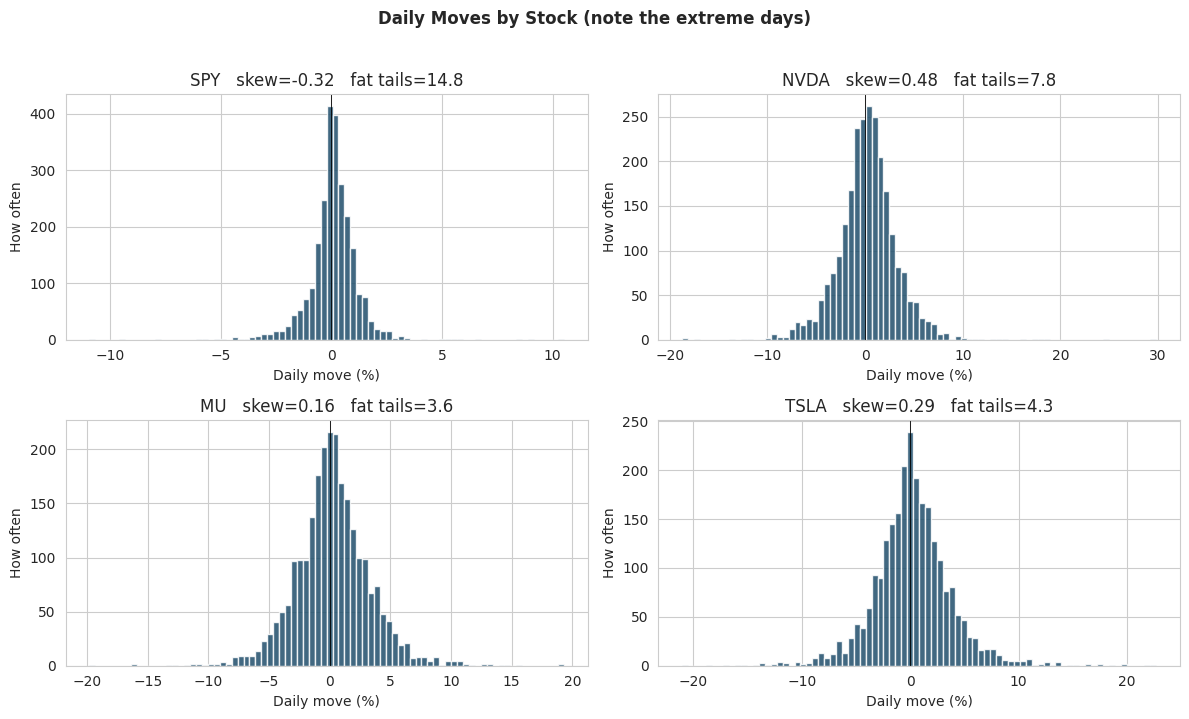

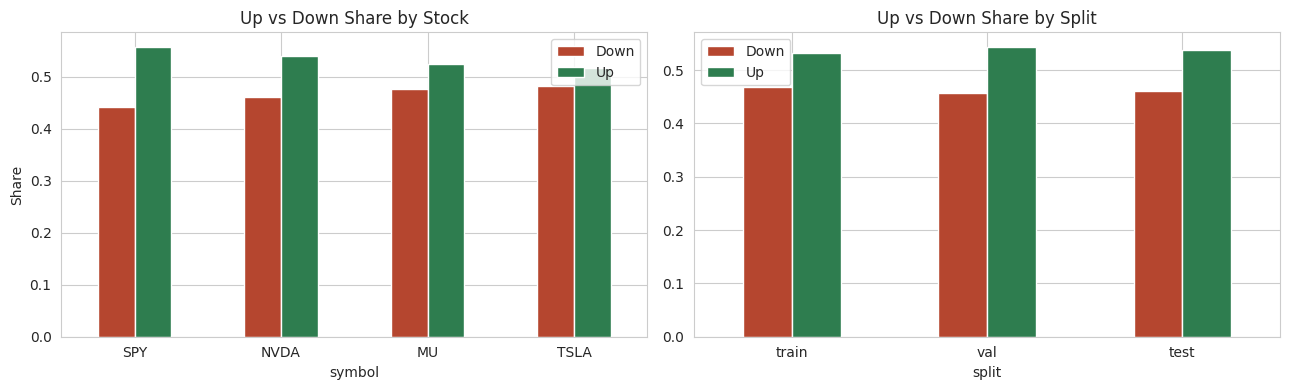

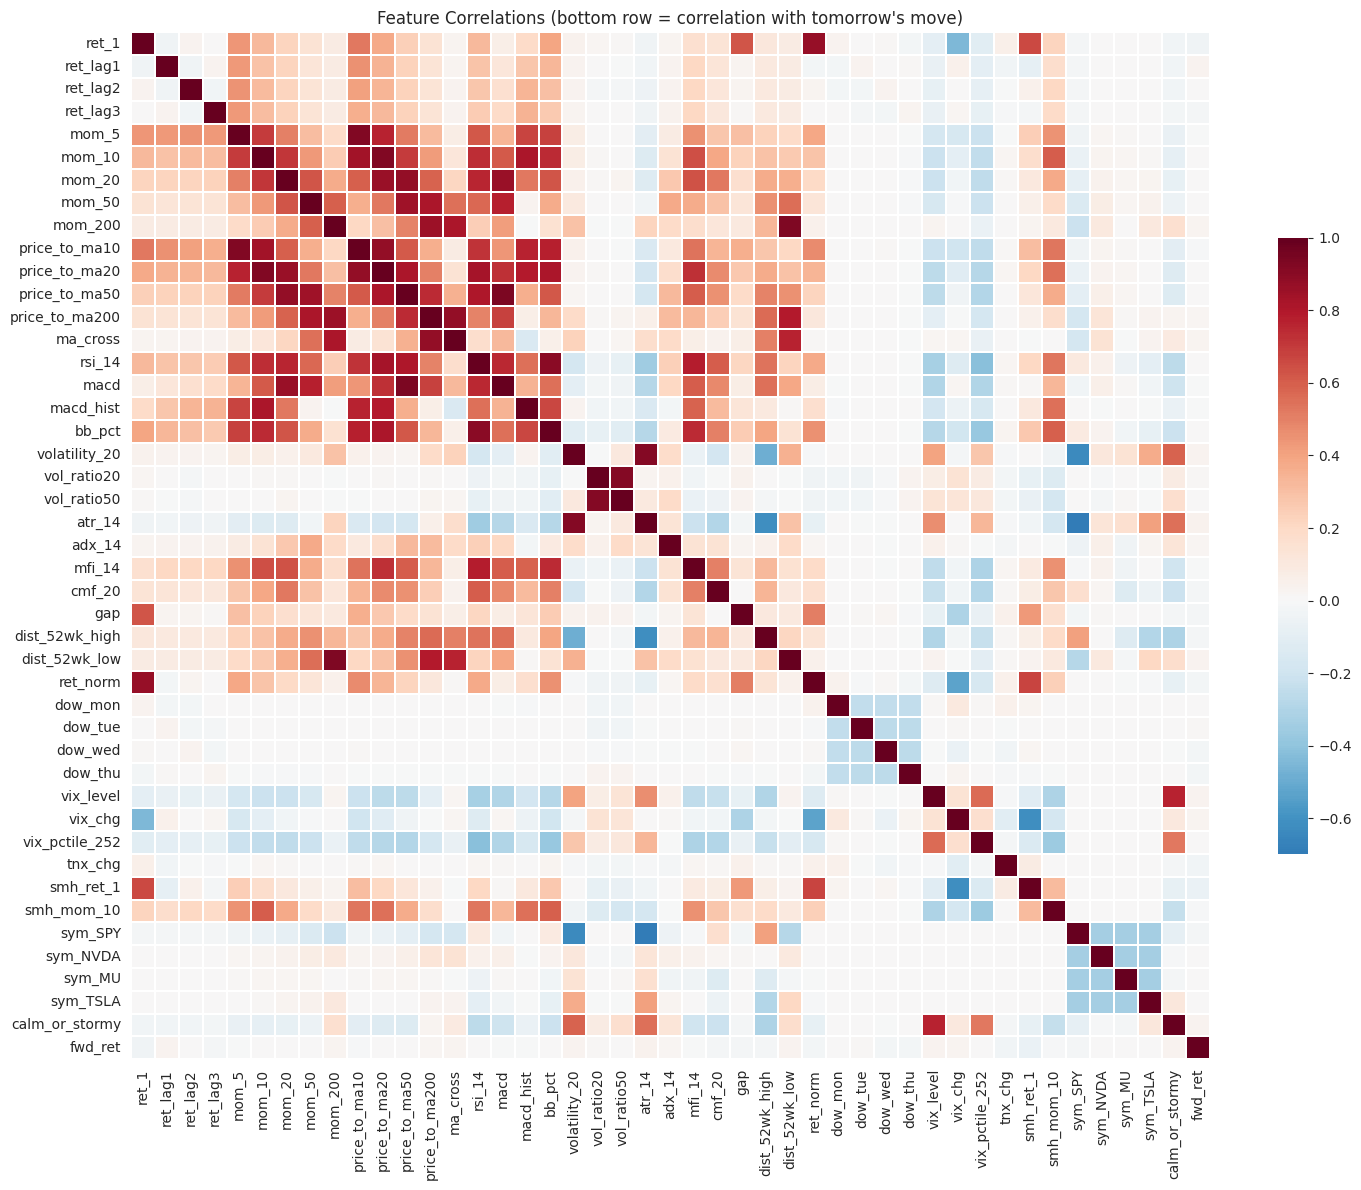

Strongest links to tomorrow's move (all tiny):
smh_ret_1        0.0636
atr_14           0.0418
ret_1            0.0417
tnx_chg          0.0388
ret_lag1         0.0369
volatility_20    0.0364
vix_level        0.0346
dist_52wk_low    0.0328


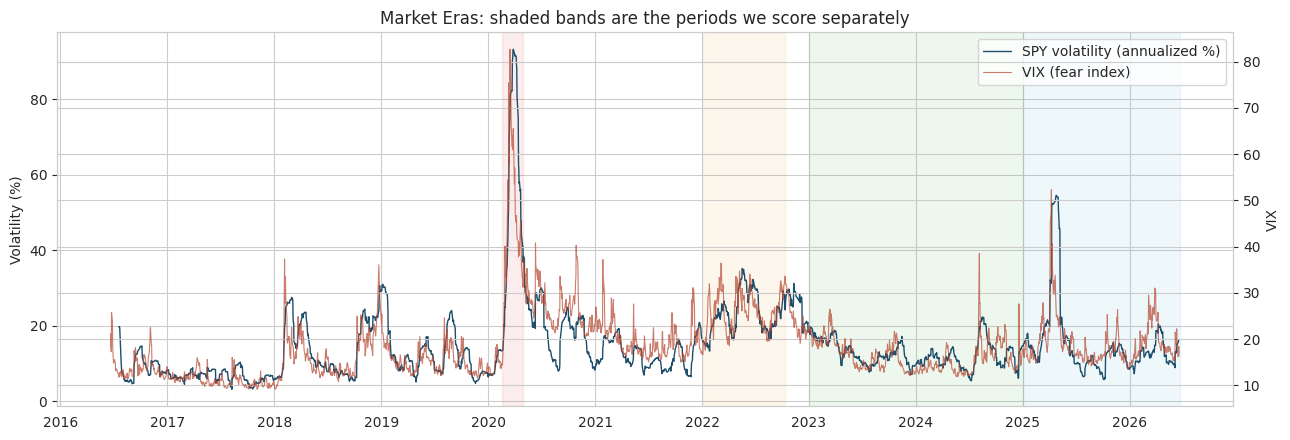

In [6]:
# Four pictures, each one backs a decision we made.

# Picture 1: daily moves are not bell shaped. Huge days happen far more often than a normal curve predicts.
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, s in zip(axes.ravel(), STOCKS):
    moves = stock_data[s]["ret_1"].dropna() * 100
    ax.hist(moves, bins=80, color="#1f4e6b", alpha=0.85)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{s}   skew={skew(moves):.2f}   fat tails={kurtosis(moves):.1f}")
    ax.set_xlabel("Daily move (%)"); ax.set_ylabel("How often")
fig.suptitle("Daily Moves by Stock (note the extreme days)", fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

# Picture 2: Up and Down days are close to 50/50, with a small Up edge. Same story in every split.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
by_stock = data.groupby("symbol")["target"].value_counts(normalize=True).unstack().reindex(STOCKS)
by_stock.columns = CLASS_NAMES
by_stock.plot(kind="bar", ax=axes[0], color=["#b5462f", "#2e7d4f"] if N_CLASSES == 2 else None)
axes[0].set_title("Up vs Down Share by Stock"); axes[0].set_ylabel("Share"); axes[0].tick_params(axis="x", rotation=0)
by_split = data.groupby("split")["target"].value_counts(normalize=True).unstack().reindex(["train", "val", "test"])
by_split.columns = CLASS_NAMES
by_split.plot(kind="bar", ax=axes[1], color=["#b5462f", "#2e7d4f"] if N_CLASSES == 2 else None)
axes[1].set_title("Up vs Down Share by Split"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

# Picture 3: no single feature predicts tomorrow. The last row of this map is nearly all white.
# That is WHY we need models that combine many weak clues.
fig, ax = plt.subplots(figsize=(15, 12))
correlations = data[FEATURE_COLS + ["fwd_ret"]].corr()
sns.heatmap(correlations, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": 0.6}, linewidths=0.2)
ax.set_title("Feature Correlations (bottom row = correlation with tomorrow's move)")
plt.tight_layout(); plt.show()
print("Strongest links to tomorrow's move (all tiny):")
print(correlations["fwd_ret"].drop("fwd_ret").abs().sort_values(ascending=False).head(8).round(4).to_string())

# Picture 4: the market moves through calm and stormy eras. One average model blends them,
# so later we also score each era separately.
fig, ax = plt.subplots(figsize=(13, 4.5))
spy_vol = stock_data["SPY"]["volatility_20"] * 100 * np.sqrt(252)
ax.plot(stock_data["SPY"].index, spy_vol, color="#1f4e6b", lw=1, label="SPY volatility (annualized %)")
ax2 = ax.twinx()
ax2.plot(market.index, market["vix_level"], color="#b5462f", lw=0.8, alpha=0.7, label="VIX (fear index)")
for (era, (a, b)), color in zip(MARKET_ERAS.items(), ["#d9534f", "#f0ad4e", "#5cb85c", "#5bc0de"]):
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=color, alpha=0.10)
ax.set_ylabel("Volatility (%)"); ax2.set_ylabel("VIX")
ax.set_title("Market Eras: shaded bands are the periods we score separately")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right")
plt.tight_layout(); plt.show()

## 6. Prepare the Data and Define the Score

Two chores and one rule. Chores: scale all features (the scaler learns from training data only) and weight rare classes slightly more.

The rule: the score is **macro F1**, always computed with the full class list. Macro F1 grades the model separately on each class then averages, so always guessing "Up" cannot look good. Forcing the full class list closes a subtle bug where a missing class silently inflates the score.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Put every feature on the same scale (average 0, spread 1). The scaler learns ONLY from training data.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

ALL_CLASSES = list(range(N_CLASSES))

def macro_f1(actual, predicted):
    """Our main score. Averages the F1 of each class EQUALLY, so ignoring a class is punished.
    We always pass the full class list. Without it, a missing class silently inflates the score."""
    return f1_score(actual, predicted, labels=ALL_CLASSES, average="macro", zero_division=0)

def score(name, actual, predicted):
    return {"model": name, "acc": round(accuracy_score(actual, predicted), 4), "macroF1": round(macro_f1(actual, predicted), 4)}

def show_confusion(actual, predicted, title):
    """Grid of actual vs predicted. Diagonal = correct calls."""
    grid = confusion_matrix(actual, predicted, labels=ALL_CLASSES)
    fig, ax = plt.subplots(figsize=(4.6, 3.8))
    sns.heatmap(grid, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Model said"); ax.set_ylabel("Actually was"); ax.set_title(title)
    plt.tight_layout(); plt.show()

# Class weights: if one class is rarer, its mistakes count a bit more during training.
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight("balanced", classes=np.arange(N_CLASSES), y=y_train)
class_weight = {i: w for i, w in enumerate(weights)}
train_weights = np.array([class_weight[c] for c in y_train])
print("class weights:", {k: round(v, 3) for k, v in class_weight.items()})

scoreboard = []   # every model's test result lands here

class weights: {0: np.float64(1.068), 1: np.float64(0.94)}


## 7. Model 1: The "Do Nothing" Baseline

Always guess the most common answer. Decent accuracy (markets drift up), terrible macro F1 (about 0.35, zero credit on down days). Every real model must beat this clearly, and it shows in one line why accuracy alone misleads.

In [8]:
# Always guess the most common answer. Any real model must beat this clearly.
most_common = np.bincount(y_train).argmax()
baseline_test = np.full_like(y_test, most_common)
baseline_val  = np.full_like(y_val, most_common)
scoreboard.append(score("Majority baseline", y_test, baseline_test))
print(scoreboard[-1])

{'model': 'Majority baseline', 'acc': 0.5386, 'macroF1': 0.35}


## 8. Model 2: Logistic Regression, Built in TensorFlow

The simplest real model: weigh every feature, add up, convert to a probability. It is the reference point; if fancier models cannot beat it, the fancy parts are not earning their keep.

Build it as a one layer network. An exact mathematical conversion makes it equal to the scikit-learn version, and the parity check below verifies agreement within about 0.005.

{'model': 'TF logistic', 'acc': 0.5047, 'macroF1': 0.5035}
  scikit-learn gets: {'model': 'sklearn logistic', 'acc': 0.5093, 'macroF1': 0.5093}


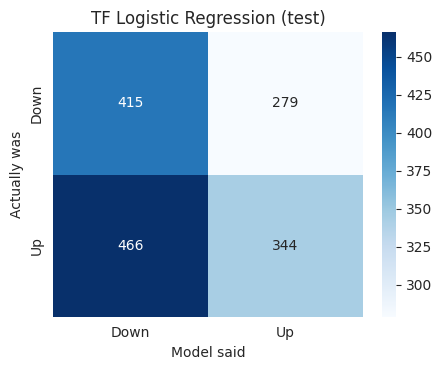

In [9]:
# Logistic regression = give every feature a weight, add them up, turn the sum into a probability.
#  we build it as a one layer network,
# then check it gets the same answer as the standard scikit-learn version.
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
tf.random.set_seed(SEED)

C = 1.0                                            # same regularization strength scikit-learn uses
l2_penalty = 1.0 / (2.0 * C * len(X_train_scaled)) # exact conversion between the two libraries' math

def train_tf_logistic(X_tr, y_tr, X_v, y_v, epochs=LOGISTIC_EPOCHS):
    model = tf.keras.Sequential([
        layers.Input((X_tr.shape[1],)),
        layers.Dense(N_CLASSES, activation="softmax", kernel_regularizer=regularizers.l2(l2_penalty)),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    sample_weights = np.array([class_weight[c] for c in y_tr])
    stop_early = callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
    slow_down  = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-5)
    model.fit(X_tr, y_tr, sample_weight=sample_weights, validation_data=(X_v, y_v),
              epochs=epochs, batch_size=1024, callbacks=[stop_early, slow_down], verbose=0)
    return model

logistic = train_tf_logistic(X_train_scaled, y_train, X_val_scaled, y_val)
logistic_val_probs  = logistic.predict(X_val_scaled, verbose=0)
logistic_test_probs = logistic.predict(X_test_scaled, verbose=0)
scoreboard.append(score("TF logistic", y_test, logistic_test_probs.argmax(1)))
print(scoreboard[-1])

# Parity check: TensorFlow and scikit-learn should agree within about 0.005
from sklearn.linear_model import LogisticRegression
sk_version = LogisticRegression(max_iter=2000, C=C, class_weight="balanced", random_state=SEED).fit(X_train_scaled, y_train)
print("  scikit-learn gets:", score("sklearn logistic", y_test, sk_version.predict(X_test_scaled)))

show_confusion(y_test, logistic_test_probs.argmax(1), "TF Logistic Regression (test)")

## 9. Model 3: XGBoost, With a Settings Search

Hundreds of small decision trees, each correcting the previous ones' mistakes. Trees learn combinations, like "high RSI means something different when the market is stormy", which a line cannot.

We try 30 random settings and keep the best scorer on **validation** data. Read three outputs: the train/val/test line (trees memorize training data, that is normal; validation staying close to test is what matters), the confusion grid, and the feature importance chart. Watch whether `calm_or_stormy` and the VIX block earn top 20 spots.

  try 01/30: val macroF1 = 0.5303 (best so far 0.5303)
  try 02/30: val macroF1 = 0.5412 (best so far 0.5412)
  try 03/30: val macroF1 = 0.4996 (best so far 0.5412)
  try 04/30: val macroF1 = 0.5182 (best so far 0.5412)
  try 05/30: val macroF1 = 0.5048 (best so far 0.5412)
  try 06/30: val macroF1 = 0.5408 (best so far 0.5412)
  try 07/30: val macroF1 = 0.5039 (best so far 0.5412)
  try 08/30: val macroF1 = 0.5368 (best so far 0.5412)
  try 09/30: val macroF1 = 0.5232 (best so far 0.5412)
  try 10/30: val macroF1 = 0.5169 (best so far 0.5412)
  try 11/30: val macroF1 = 0.5293 (best so far 0.5412)
  try 12/30: val macroF1 = 0.5319 (best so far 0.5412)
  try 13/30: val macroF1 = 0.5127 (best so far 0.5412)
  try 14/30: val macroF1 = 0.5064 (best so far 0.5412)
  try 15/30: val macroF1 = 0.5347 (best so far 0.5412)
  try 16/30: val macroF1 = 0.5079 (best so far 0.5412)
  try 17/30: val macroF1 = 0.4753 (best so far 0.5412)
  try 18/30: val macroF1 = 0.5240 (best so far 0.5412)
  try 19/3

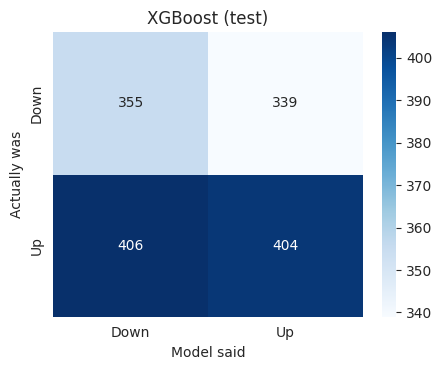

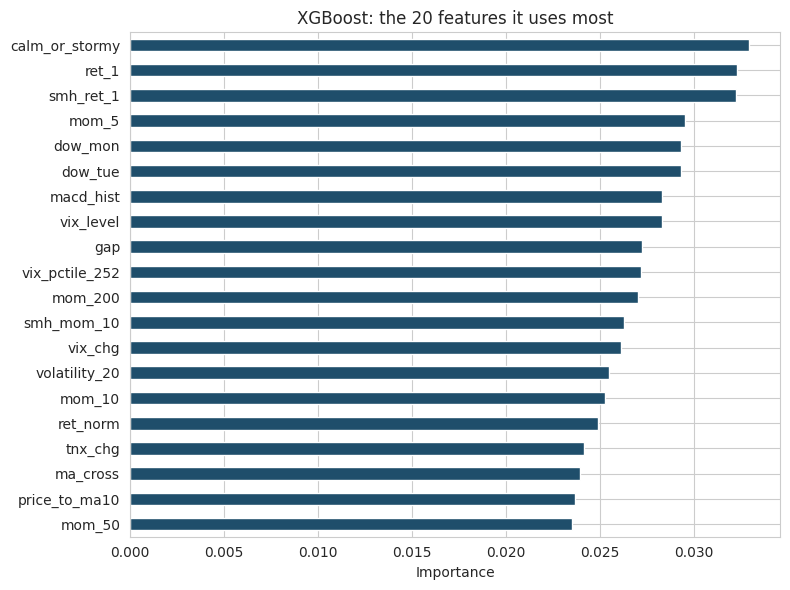

In [10]:
# XGBoost builds many small decision trees, each fixing the previous ones' mistakes.
# Trees can learn combinations like "high RSI matters MORE when the market is stormy",
# which a straight line model cannot.
# We try XGB_TRIES random settings and keep whichever scores best on VALIDATION data.
from xgboost import XGBClassifier

random_picker = np.random.RandomState(SEED)
options = {
    "max_depth":        [3, 4, 6],          # how deep each tree may go
    "learning_rate":    [0.01, 0.03, 0.1],  # how big each correction step is
    "subsample":        [0.7, 0.8, 0.9],    # share of rows each tree sees
    "colsample_bytree": [0.5, 0.7, 0.9],    # share of features each tree sees
    "reg_lambda":       [1.0, 5.0, 10.0],   # penalty against overcomplicated trees
    "min_child_weight": [1, 5, 20],         # minimum data needed to make a split
}
def random_settings():
    return {k: v[random_picker.randint(len(v))] for k, v in options.items()}

best = {"f1": -1, "settings": None, "model": None}
for i in range(XGB_TRIES):
    settings = random_settings()
    candidate = XGBClassifier(n_estimators=2000, early_stopping_rounds=50,
                              eval_metric="mlogloss" if N_CLASSES > 2 else "logloss",
                              random_state=SEED, verbosity=0, **settings)
    candidate.fit(X_train, y_train, sample_weight=train_weights, eval_set=[(X_val, y_val)], verbose=False)
    val_f1 = macro_f1(y_val, candidate.predict(X_val))
    if val_f1 > best["f1"]:
        best = {"f1": val_f1, "settings": settings, "model": candidate}
    print(f"  try {i+1:02d}/{XGB_TRIES}: val macroF1 = {val_f1:.4f} (best so far {best['f1']:.4f})")

xgboost_model = best["model"]
print("winning settings:", best["settings"])
xgboost_val_probs  = xgboost_model.predict_proba(X_val)
xgboost_test_probs = xgboost_model.predict_proba(X_test)
scoreboard.append(score("XGBoost (tuned)", y_test, xgboost_test_probs.argmax(1)))
print(scoreboard[-1])

# Overfitting check: trees memorize training data (high train score is normal).
# What matters is that the validation and test scores stay close to each other.
print("  XGBoost macroF1 on train / val / test:",
      round(macro_f1(y_train, xgboost_model.predict(X_train)), 3),
      round(macro_f1(y_val, xgboost_model.predict(X_val)), 3),
      round(macro_f1(y_test, xgboost_model.predict(X_test)), 3))

show_confusion(y_test, xgboost_test_probs.argmax(1), "XGBoost (test)")

# Which features does XGBoost actually rely on?
importance = pd.Series(xgboost_model.feature_importances_, index=FEATURE_COLS).nlargest(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind="barh", ax=ax, color="#1f4e6b")
ax.set_title("XGBoost: the 20 features it uses most"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

## 10. Model 4: Random Forest

A team of trees voting independently.

In [11]:
# Also many trees, but each votes independently instead of correcting the last one.
from sklearn.ensemble import RandomForestClassifier
forest_options = [{"max_depth": d, "min_samples_leaf": l} for d in (4, 6, 8, 10) for l in (20, 50, 100)]
best_forest = {"f1": -1, "model": None, "settings": None}
for settings in (forest_options[:2] if QUICK else forest_options):
    candidate = RandomForestClassifier(n_estimators=100 if QUICK else 400, max_features="sqrt",
                                       class_weight="balanced", random_state=SEED, n_jobs=-1, **settings)
    candidate.fit(X_train, y_train)
    val_f1 = macro_f1(y_val, candidate.predict(X_val))
    if val_f1 > best_forest["f1"]:
        best_forest = {"f1": val_f1, "model": candidate, "settings": settings}
forest = best_forest["model"]
print("winning settings:", best_forest["settings"], "| val macroF1:", round(best_forest["f1"], 4))
scoreboard.append(score("Random Forest (tuned)", y_test, forest.predict(X_test)))
print(scoreboard[-1])

winning settings: {'max_depth': 10, 'min_samples_leaf': 50} | val macroF1: 0.5363
{'model': 'Random Forest (tuned)', 'acc': 0.5286, 'macroF1': 0.5265}


## 11. Model 5: LSTM, Built in TensorFlow

Reads the last 20 days as a sequence, in order. Question: is there extra pattern in the order of recent days beyond what the momentum features already capture? Windows are built per stock so histories never mix. If the LSTM only ties logistic regression, that is a reportable finding: the engineered features already capture what recent history has to say.

sequence shapes: (5960, 20, 44) (1508, 20, 44) (1504, 20, 44)
{'model': 'LSTM', 'acc': 0.5, 'macroF1': 0.4968}


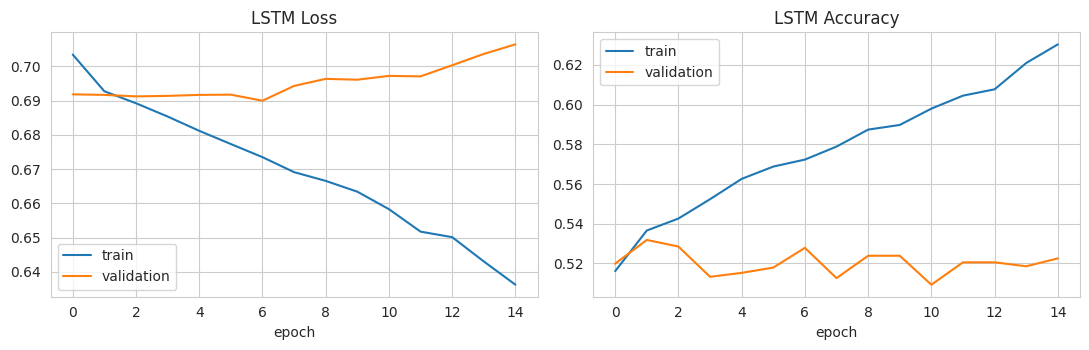

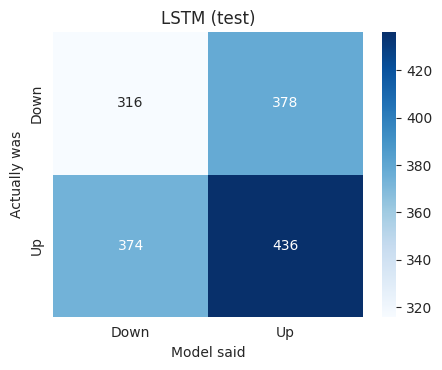

In [12]:
# The LSTM reads the last 20 days as a sequence instead of a single snapshot.
# Question it answers: is there extra pattern in the ORDER of recent days
# beyond what our momentum and lag features already capture?
def slice_into_windows(features, dates, splits, targets, window):
    """Turn a stock's day by day table into overlapping 20 day strips. The label belongs to the LAST day."""
    X, y, when, part = [], [], [], []
    for start in range(len(features) - window + 1):
        end = start + window - 1
        X.append(features[start:start + window]); y.append(targets[end]); when.append(dates[end]); part.append(splits[end])
    return np.array(X, dtype="float32"), np.array(y), np.array(when), np.array(part)

pieces_X, pieces_y, pieces_when, pieces_part, pieces_stock = [], [], [], [], []
for s in STOCKS:   # windows are built per stock, so one stock's history never bleeds into another's
    one = data[data.symbol == s].sort_index()
    scaled = scaler.transform(one[FEATURE_COLS].values).astype("float32")
    Xw, yw, whenw, partw = slice_into_windows(scaled, one.index.values, one["split"].values, one["target"].values, LSTM_WINDOW)
    pieces_X.append(Xw); pieces_y.append(yw); pieces_when.append(whenw); pieces_part.append(partw)
    pieces_stock.append(np.array([s] * len(yw)))
seq_X = np.concatenate(pieces_X); seq_y = np.concatenate(pieces_y).astype(int)
seq_when = np.concatenate(pieces_when); seq_part = np.concatenate(pieces_part); seq_stock = np.concatenate(pieces_stock)

def sequences_for(split):
    keep = seq_part == split
    return seq_X[keep], seq_y[keep]
seqX_train, seqy_train = sequences_for("train")
seqX_val,   seqy_val   = sequences_for("val")
seqX_test,  seqy_test  = sequences_for("test")
print("sequence shapes:", seqX_train.shape, seqX_val.shape, seqX_test.shape)

lstm = tf.keras.Sequential([
    layers.Input((LSTM_WINDOW, seq_X.shape[2])),
    layers.LSTM(64, recurrent_dropout=0.2),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(N_CLASSES, activation="softmax"),
])
lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq_weights = np.array([class_weight[c] for c in seqy_train])
history = lstm.fit(seqX_train, seqy_train, sample_weight=seq_weights, validation_data=(seqX_val, seqy_val),
                   epochs=LSTM_EPOCHS, batch_size=64, verbose=0,
                   callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)])
lstm_val_probs  = lstm.predict(seqX_val, verbose=0)
lstm_test_probs = lstm.predict(seqX_test, verbose=0)
scoreboard.append(score("LSTM", seqy_test, lstm_test_probs.argmax(1)))
print(scoreboard[-1])

# Training curves: the moment the orange (validation) line stops improving is where learning ends.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(history.history["loss"], label="train"); axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("LSTM Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train"); axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("LSTM Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()
show_confusion(seqy_test, lstm_test_probs.argmax(1), "LSTM (test)")

## 12. Pick a Better Decision Cutoff

Models output probabilities. Someone must pick the cutoff that turns "62% Up" into a call. The default 0.5 is not automatically best for macro F1, so we test cutoffs 0.30 to 0.70 on **validation** data, keep the winner, then apply it once to test. Free improvement, no retraining.

{'model': 'TF logistic (cutoff 0.50)', 'acc': 0.5047, 'macroF1': 0.5035}
{'model': 'XGBoost (cutoff 0.50)', 'acc': 0.5047, 'macroF1': 0.5041}
{'model': 'LSTM (cutoff 0.49)', 'acc': 0.5033, 'macroF1': 0.4941}


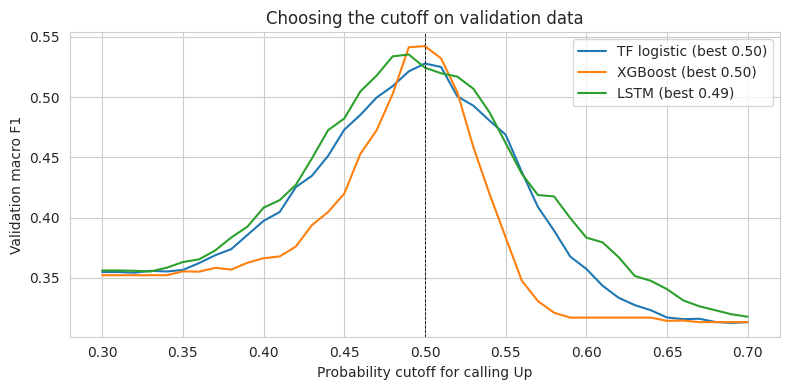

In [13]:
# Models output a probability, like "62% chance of Up". Someone must choose the cutoff
# that turns probability into a call. The default 0.5 is not always best for macro F1,
# so we try cutoffs from 0.30 to 0.70 on VALIDATION data, keep the winner, and only then touch test.
def try_cutoffs(val_probs, val_actual):
    cutoffs = np.arange(0.30, 0.71, 0.01)
    scores = [macro_f1(val_actual, (val_probs[:, 1] >= c).astype(int)) for c in cutoffs]
    return cutoffs, np.array(scores)

if TARGET_MODE == "binary":
    fig, ax = plt.subplots(figsize=(8, 4))
    for name, val_p, test_p, val_a, test_a in [
        ("TF logistic", logistic_val_probs, logistic_test_probs, y_val, y_test),
        ("XGBoost",     xgboost_val_probs,  xgboost_test_probs,  y_val, y_test),
        ("LSTM",        lstm_val_probs,     lstm_test_probs,     seqy_val, seqy_test)]:
        cutoffs, scores = try_cutoffs(val_p, val_a)
        best_cutoff = cutoffs[scores.argmax()]
        ax.plot(cutoffs, scores, label=f"{name} (best {best_cutoff:.2f})")
        calls = (test_p[:, 1] >= best_cutoff).astype(int)
        scoreboard.append(score(f"{name} (cutoff {best_cutoff:.2f})", test_a, calls))
        print(scoreboard[-1])
    ax.axvline(0.5, color="k", lw=0.6, ls="--")
    ax.set_xlabel("Probability cutoff for calling Up"); ax.set_ylabel("Validation macro F1")
    ax.set_title("Choosing the cutoff on validation data"); ax.legend()
    plt.tight_layout(); plt.show()

## 13. Combine the Models (Ensemble)

Different model types make different mistakes. Averaging their probabilities cancels some noise, like averaging imperfect thermometers. Blend weights are chosen on validation data. If all weight lands on one model, the others add nothing, and we say so.

In [14]:
# Different model types make different mistakes. Averaging their probabilities cancels some noise.
# The blend weights are chosen on validation data.
# Small detail: the LSTM covers slightly fewer days (it needs 20 days of warmup),
# so we line the other models' predictions up to the same days first, matched by stock and date.
sequence_index = pd.DataFrame({"date": pd.to_datetime(seq_when), "split": seq_part, "symbol": seq_stock})
sequence_index["seq_row"] = np.arange(len(sequence_index))
table_index = data.reset_index()
table_index["table_row"] = np.arange(len(table_index))
matched = sequence_index.merge(table_index[["date", "symbol", "table_row", "split"]], on=["date", "symbol"], suffixes=("", "_t"))
assert (matched["split"] == matched["split_t"]).all()

def align_to_sequences(table_probs, split):
    """Reorder a flat model's predictions so row i matches sequence row i."""
    rows_in_split = table_index[table_index["split"] == split]["table_row"].values
    position = {row: i for i, row in enumerate(rows_in_split)}
    same_split = matched[matched["split"] == split].sort_values("seq_row")
    return table_probs[[position[r] for r in same_split["table_row"].values]]

logistic_val_lined  = align_to_sequences(logistic_val_probs, "val")
logistic_test_lined = align_to_sequences(logistic_test_probs, "test")
xgboost_val_lined   = align_to_sequences(xgboost_val_probs, "val")
xgboost_test_lined  = align_to_sequences(xgboost_test_probs, "test")

best_blend = {"f1": -1, "weights": None}
steps = np.arange(0, 1.01, 0.25)
for w_logistic in steps:
    for w_xgboost in steps:
        w_lstm = 1 - w_logistic - w_xgboost
        if w_lstm < -1e-9: continue
        blend = w_logistic*logistic_val_lined + w_xgboost*xgboost_val_lined + max(w_lstm, 0)*lstm_val_probs
        f1 = macro_f1(seqy_val, blend.argmax(1))
        if f1 > best_blend["f1"]:
            best_blend = {"f1": f1, "weights": (w_logistic, w_xgboost, max(w_lstm, 0))}
wl, wx, wm = best_blend["weights"]
ensemble_val_probs  = wl*logistic_val_lined + wx*xgboost_val_lined + wm*lstm_val_probs
ensemble_test_probs = wl*logistic_test_lined + wx*xgboost_test_lined + wm*lstm_test_probs
print(f"blend weights (logistic, xgboost, lstm) = {best_blend['weights']} | val macroF1 = {best_blend['f1']:.4f}")
scoreboard.append(score("Ensemble", seqy_test, ensemble_test_probs.argmax(1)))
print(scoreboard[-1])
if TARGET_MODE == "binary":
    cutoffs, scores = try_cutoffs(ensemble_val_probs, seqy_val)
    c = cutoffs[scores.argmax()]
    scoreboard.append(score(f"Ensemble (cutoff {c:.2f})", seqy_test, (ensemble_test_probs[:, 1] >= c).astype(int)))
    print(scoreboard[-1])

blend weights (logistic, xgboost, lstm) = (np.float64(0.25), np.float64(0.75), np.float64(0.0)) | val macroF1 = 0.5584
{'model': 'Ensemble', 'acc': 0.5106, 'macroF1': 0.5106}
{'model': 'Ensemble (cutoff 0.50)', 'acc': 0.5106, 'macroF1': 0.5106}


## 14. Meta Labeling: A Second Model That Audits the First

From Lopez de Prado's *Advances in Financial Machine Learning* (2018), a technique designed specifically to raise F1.

The primary model (tuned XGBoost) makes its call. Then a small **auditor** model predicts whether that call is likely right or wrong, looking at market conditions (our regime score, VIX, volatility) and the primary's own confidence. The auditor trains on validation days, where the primary's mistakes are honest because it never trained there.

Two ways to use the auditor:

1. **Correction, full coverage**: flip the primary's call on days the auditor says it is probably wrong. Directly comparable in the main table.
2. **Selective mode, the original design**: only act on days the auditor trusts. Fewer days scored, better calls. We report score against coverage honestly; subset scores are labeled and never mixed into the main table.

The coverage curve is also drawn **inside each market era**. This regime conditional selective view (does trusting the auditor buy more in stormy periods than calm ones?) is essentially absent from the published literature, and it is one of the project's ownable contributions.

auditor trains on 1508 validation days; primary was right on 54.3% of them
auditor flipped 456 of 1504 test calls
{'model': 'XGBoost + meta correction', 'acc': 0.518, 'macroF1': 0.4964}

=== SELECTIVE MODE: score when we only act on trusted days ===
    coverage  days_scored  macroF1_on_those_days
100% of days         1504                 0.5041
 80% of days         1203                 0.5044
 60% of days          902                 0.4945
 40% of days          601                 0.4636
(These subset scores are labeled with their coverage and are NOT comparable to full table numbers.)


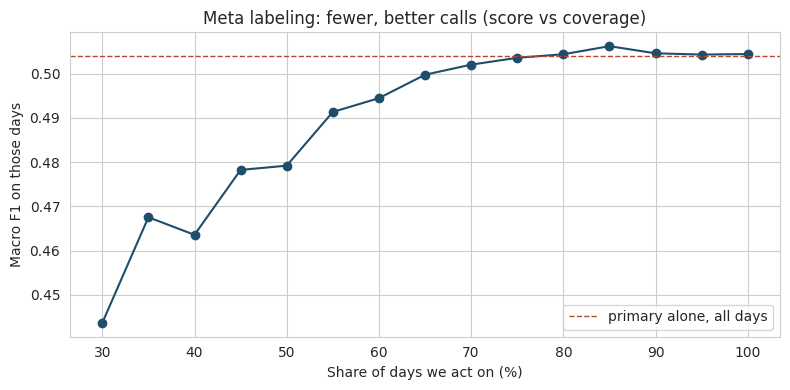

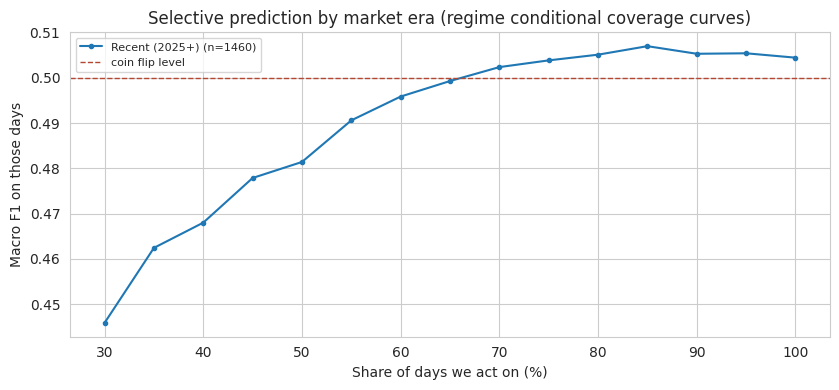

In [15]:
# Idea from Lopez de Prado (Advances in Financial Machine Learning, 2018), built to raise F1.
# The primary model (our tuned XGBoost) makes its call. A second, smaller model then predicts
# whether that call is likely RIGHT or WRONG, using the market's condition and the primary's own confidence.
# The auditor trains on VALIDATION days, where the primary's mistakes are honest (it never trained there).
if TARGET_MODE == "binary":
    META_INPUTS = ["calm_or_stormy", "vix_level", "volatility_20", "atr_14", "adx_14"]

    def auditor_inputs(split, primary_probs):
        """Market conditions plus the primary model's probability and how confident it was."""
        conditions = data[data.split == split][META_INPUTS].values
        p_up = primary_probs[:, 1:2]
        confidence = np.abs(p_up - 0.5)
        return np.hstack([conditions, p_up, confidence])

    primary_val_call  = xgboost_val_probs.argmax(1)
    primary_test_call = xgboost_test_probs.argmax(1)

    auditor_X = auditor_inputs("val", xgboost_val_probs)
    auditor_y = (primary_val_call == y_val).astype(int)      # 1 = the primary was right that day
    print(f"auditor trains on {len(auditor_y)} validation days; primary was right on {auditor_y.mean():.1%} of them")

    auditor = XGBClassifier(max_depth=2, n_estimators=200, learning_rate=0.05,
                            subsample=0.9, random_state=SEED, verbosity=0)
    auditor.fit(auditor_X, auditor_y)
    p_primary_right = auditor.predict_proba(auditor_inputs("test", xgboost_test_probs))[:, 1]

    # Use 1: full coverage. Where the auditor says the primary is probably wrong, flip the call.
    corrected_call = np.where(p_primary_right >= 0.5, primary_test_call, 1 - primary_test_call)
    flipped = int((corrected_call != primary_test_call).sum())
    scoreboard.append(score("XGBoost + meta correction", y_test, corrected_call))
    print(f"auditor flipped {flipped} of {len(y_test)} test calls")
    print(scoreboard[-1])

    # Use 2: selective mode, the original design. Only act on days the auditor trusts.
    # Fewer days scored, but the calls that remain should be better. We report score vs coverage honestly.
    trust_order = np.argsort(-p_primary_right)
    coverage_rows = []
    for share in [1.0, 0.8, 0.6, 0.4]:
        kept = trust_order[:int(len(trust_order) * share)]
        coverage_rows.append({"coverage": f"{int(share*100)}% of days",
                              "days_scored": len(kept),
                              "macroF1_on_those_days": round(macro_f1(y_test[kept], primary_test_call[kept]), 4)})
    coverage_table = pd.DataFrame(coverage_rows)
    print("\n=== SELECTIVE MODE: score when we only act on trusted days ===")
    print(coverage_table.to_string(index=False))
    print("(These subset scores are labeled with their coverage and are NOT comparable to full table numbers.)")

    shares = np.arange(0.30, 1.001, 0.05)
    curve = [macro_f1(y_test[trust_order[:int(len(trust_order)*s)]],
                      primary_test_call[trust_order[:int(len(trust_order)*s)]]) for s in shares]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(shares * 100, curve, marker="o", color="#1f4e6b")
    ax.axhline(macro_f1(y_test, primary_test_call), color="#b5462f", ls="--", lw=1, label="primary alone, all days")
    ax.set_xlabel("Share of days we act on (%)"); ax.set_ylabel("Macro F1 on those days")
    ax.set_title("Meta labeling: fewer, better calls (score vs coverage)")
    ax.legend(); plt.tight_layout(); plt.show()

    # The same curve inside each market era. The research question: does selectivity buy MORE
    # in some regimes than others? Almost no published work reports this view.
    test_dates_index = data[data.split == "test"].index
    fig, ax = plt.subplots(figsize=(8.5, 4))
    for era, (a, b) in MARKET_ERAS.items():
        inside = np.asarray((test_dates_index >= pd.Timestamp(a)) & (test_dates_index <= pd.Timestamp(b)))
        if inside.sum() < 200: continue
        p_in, y_in, call_in = p_primary_right[inside], y_test[inside], primary_test_call[inside]
        order_in = np.argsort(-p_in)
        curve_in = [macro_f1(y_in[order_in[:max(int(len(order_in)*s), 20)]],
                             call_in[order_in[:max(int(len(order_in)*s), 20)]]) for s in shares]
        ax.plot(shares * 100, curve_in, marker=".", label=f"{era} (n={int(inside.sum())})")
    ax.axhline(0.5, color="#b5462f", ls="--", lw=1, label="coin flip level")
    ax.set_xlabel("Share of days we act on (%)"); ax.set_ylabel("Macro F1 on those days")
    ax.set_title("Selective prediction by market era (regime conditional coverage curves)")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 15. Compare Every Model

The payoff table: validation score, test score, and the gap. Small gap = the model generalizes. Big gap = we fooled ourselves during tuning. Two charts: test score by model against the coin flip line, and validation vs test side by side. The heart of the report's Results section.

=== MODEL COMPARISON ===
            model  val_macroF1  test_macroF1  test_acc  rows_scored  val_minus_test
Majority baseline       0.3522        0.3500    0.5386         1504          0.0022
      TF logistic       0.5279        0.5035    0.5047         1504          0.0244
    Random Forest       0.5363        0.5265    0.5286         1504          0.0098
          XGBoost       0.5423        0.5041    0.5047         1504          0.0382
             LSTM       0.5244        0.4968    0.5000         1504          0.0276
         Ensemble       0.5584        0.5106    0.5106         1504          0.0478

(LSTM and Ensemble score on slightly fewer rows because of the 20 day warmup.)


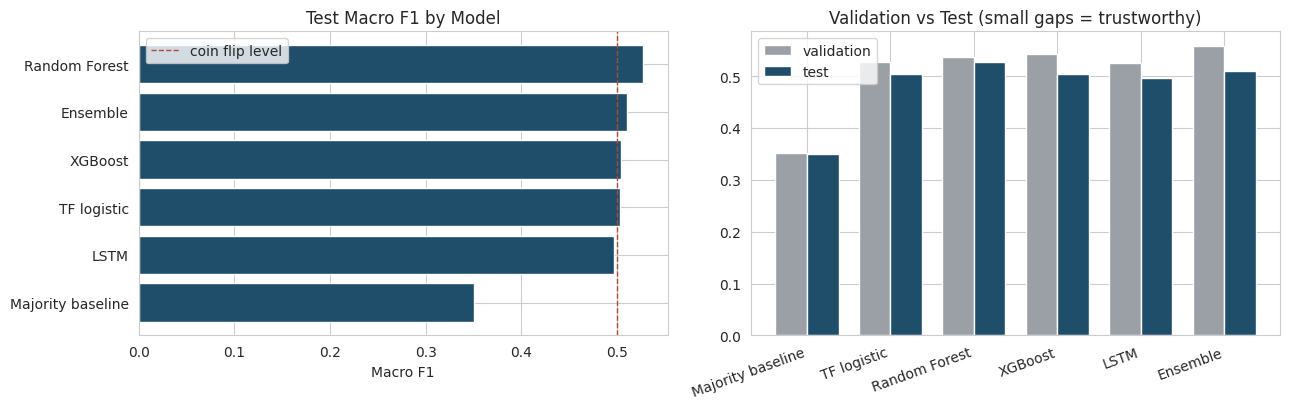


=== EVERY RESULT, INCLUDING TUNED CUTOFFS ===
                    model    acc  macroF1
        Majority baseline 0.5386   0.3500
              TF logistic 0.5047   0.5035
          XGBoost (tuned) 0.5047   0.5041
    Random Forest (tuned) 0.5286   0.5265
                     LSTM 0.5000   0.4968
TF logistic (cutoff 0.50) 0.5047   0.5035
    XGBoost (cutoff 0.50) 0.5047   0.5041
       LSTM (cutoff 0.49) 0.5033   0.4941
                 Ensemble 0.5106   0.5106
   Ensemble (cutoff 0.50) 0.5106   0.5106
XGBoost + meta correction 0.5180   0.4964


In [16]:
# One table: validation score, test score, and the gap between them.
# A small gap means the model generalizes. A big gap means we fooled ourselves during tuning.
summary = pd.DataFrame([
    {"model": "Majority baseline", "val_macroF1": macro_f1(y_val, baseline_val),                    "test_macroF1": macro_f1(y_test, baseline_test),                  "test_acc": accuracy_score(y_test, baseline_test),                  "rows_scored": len(y_test)},
    {"model": "TF logistic",       "val_macroF1": macro_f1(y_val, logistic_val_probs.argmax(1)),    "test_macroF1": macro_f1(y_test, logistic_test_probs.argmax(1)),  "test_acc": accuracy_score(y_test, logistic_test_probs.argmax(1)), "rows_scored": len(y_test)},
    {"model": "Random Forest",     "val_macroF1": macro_f1(y_val, forest.predict(X_val)),           "test_macroF1": macro_f1(y_test, forest.predict(X_test)),         "test_acc": accuracy_score(y_test, forest.predict(X_test)),        "rows_scored": len(y_test)},
    {"model": "XGBoost",           "val_macroF1": macro_f1(y_val, xgboost_val_probs.argmax(1)),     "test_macroF1": macro_f1(y_test, xgboost_test_probs.argmax(1)),   "test_acc": accuracy_score(y_test, xgboost_test_probs.argmax(1)),  "rows_scored": len(y_test)},
    {"model": "LSTM",              "val_macroF1": macro_f1(seqy_val, lstm_val_probs.argmax(1)),     "test_macroF1": macro_f1(seqy_test, lstm_test_probs.argmax(1)),   "test_acc": accuracy_score(seqy_test, lstm_test_probs.argmax(1)),  "rows_scored": len(seqy_test)},
    {"model": "Ensemble",          "val_macroF1": macro_f1(seqy_val, ensemble_val_probs.argmax(1)), "test_macroF1": macro_f1(seqy_test, ensemble_test_probs.argmax(1)),"test_acc": accuracy_score(seqy_test, ensemble_test_probs.argmax(1)),"rows_scored": len(seqy_test)},
]).round(4)
summary["val_minus_test"] = (summary["val_macroF1"] - summary["test_macroF1"]).round(4)
print("=== MODEL COMPARISON ===")
print(summary.to_string(index=False))
print("\n(LSTM and Ensemble score on slightly fewer rows because of the 20 day warmup.)")

chance = 0.5 if N_CLASSES == 2 else 0.2
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ranked = summary.sort_values("test_macroF1")
axes[0].barh(ranked["model"], ranked["test_macroF1"], color="#1f4e6b")
axes[0].axvline(chance, color="#b5462f", ls="--", lw=1, label="coin flip level")
axes[0].set_title("Test Macro F1 by Model"); axes[0].set_xlabel("Macro F1"); axes[0].legend()
positions = np.arange(len(summary)); width = 0.38
axes[1].bar(positions - width/2, summary["val_macroF1"], width, label="validation", color="#9aa0a6")
axes[1].bar(positions + width/2, summary["test_macroF1"], width, label="test", color="#1f4e6b")
axes[1].set_xticks(positions); axes[1].set_xticklabels(summary["model"], rotation=20, ha="right")
axes[1].set_title("Validation vs Test (small gaps = trustworthy)"); axes[1].legend()
plt.tight_layout(); plt.show()

full_scoreboard = pd.DataFrame(scoreboard)
print("\n=== EVERY RESULT, INCLUDING TUNED CUTOFFS ===")
print(full_scoreboard.to_string(index=False))

## 16. Experiment: Does Removing Crash Periods Help?

Retrain the two main models with the COVID crash and the 2022 bear deleted from training (validation and test untouched), then compare. Either answer is useful: if removal helps, crashes distort training; if not, we keep the full history and say why, with evidence.

training rows: 6036 with crashes, 5048 without (988 removed)

=== CRASH REMOVAL EXPERIMENT ===
      model      trained on  test_macroF1
TF logistic    full history        0.5035
TF logistic crashes removed        0.5109
    XGBoost    full history        0.5041
    XGBoost crashes removed        0.3500


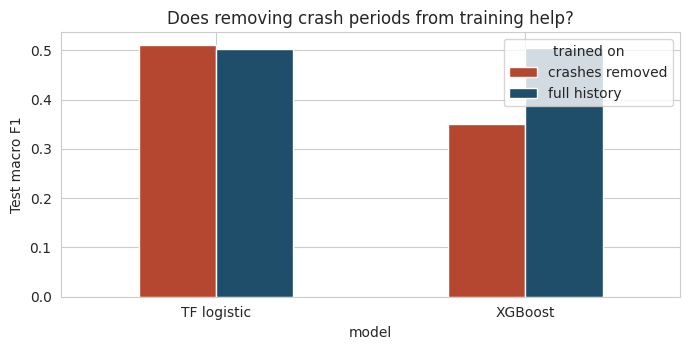

In [17]:
# We retrain the two main models WITHOUT the COVID crash and the 2022 bear market
# in the training data. Validation and test stay exactly the same. Then we compare.
in_crash = pd.Series(False, index=data.index)
for a, b in CRASH_PERIODS.values():
    in_crash |= (data.index >= pd.Timestamp(a)) & (data.index <= pd.Timestamp(b))
keep_rows = ~((data["split"] == "train").values & in_crash.values)
data_no_crash = data[keep_rows]
X_train2 = data_no_crash[data_no_crash.split == "train"][FEATURE_COLS].values
y_train2 = data_no_crash[data_no_crash.split == "train"]["target"].values
print(f"training rows: {len(X_train)} with crashes, {len(X_train2)} without ({len(X_train)-len(X_train2)} removed)")

scaler2 = StandardScaler().fit(X_train2)
weights2 = np.array([class_weight[c] for c in y_train2])
logistic2 = train_tf_logistic(scaler2.transform(X_train2), y_train2, scaler2.transform(X_val), y_val)
xgboost2 = XGBClassifier(n_estimators=2000, early_stopping_rounds=50,
                         eval_metric="mlogloss" if N_CLASSES > 2 else "logloss",
                         random_state=SEED, verbosity=0, **best["settings"])
xgboost2.fit(X_train2, y_train2, sample_weight=weights2, eval_set=[(X_val, y_val)], verbose=False)

experiment = pd.DataFrame([
    {"model": "TF logistic", "trained on": "full history",     "test_macroF1": round(macro_f1(y_test, logistic_test_probs.argmax(1)), 4)},
    {"model": "TF logistic", "trained on": "crashes removed",  "test_macroF1": round(macro_f1(y_test, logistic2.predict(scaler2.transform(X_test), verbose=0).argmax(1)), 4)},
    {"model": "XGBoost",     "trained on": "full history",     "test_macroF1": round(macro_f1(y_test, xgboost_test_probs.argmax(1)), 4)},
    {"model": "XGBoost",     "trained on": "crashes removed",  "test_macroF1": round(macro_f1(y_test, xgboost2.predict(X_test)), 4)},
])
print("\n=== CRASH REMOVAL EXPERIMENT ===")
print(experiment.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.6))
experiment.pivot(index="model", columns="trained on", values="test_macroF1").plot(kind="bar", ax=ax, color=["#b5462f", "#1f4e6b"])
ax.set_title("Does removing crash periods from training help?")
ax.set_ylabel("Test macro F1"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 17. Score by Stock and by Era

One average can hide a model that works on NVDA and fails on SPY. We break the test score out per stock and per market era. SPY is an index everyone trades, so it is plausibly harder to predict than a single volatile name; the data will say.

=== SCORE BY STOCK (test period) ===
stock  days  logistic_macroF1  xgboost_macroF1
  SPY   376             0.533            0.484
 NVDA   376             0.531            0.524
   MU   376             0.446            0.470
 TSLA   376             0.465            0.508

=== SCORE BY ERA (only eras that overlap the test period) ===
                 era  days  logistic_macroF1  xgboost_macroF1
AI rally (2023-2024)    44             0.521            0.491
      Recent (2025+)  1460             0.503            0.504


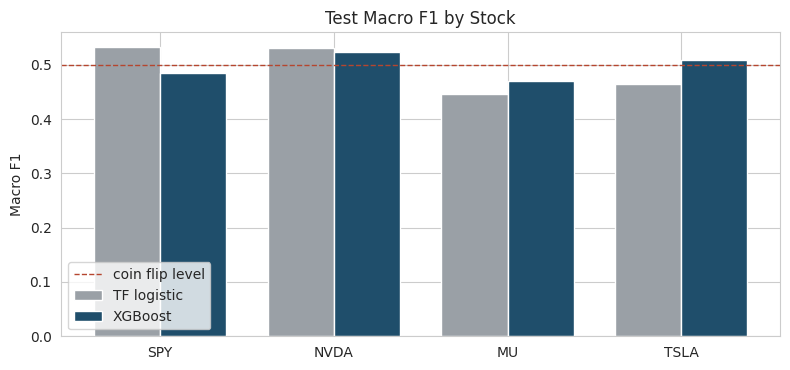

In [18]:
# An average score can hide a model that works on one stock and fails on another. So we break it out.
test_part = data[data.split == "test"].copy()
test_part["xgboost_call"]  = xgboost_test_probs.argmax(1)
test_part["logistic_call"] = logistic_test_probs.argmax(1)

by_stock_rows = []
for s in STOCKS:
    one = test_part[test_part.symbol == s]
    by_stock_rows.append({"stock": s, "days": len(one),
                          "logistic_macroF1": round(macro_f1(one["target"], one["logistic_call"]), 3),
                          "xgboost_macroF1":  round(macro_f1(one["target"], one["xgboost_call"]), 3)})
by_stock = pd.DataFrame(by_stock_rows)
print("=== SCORE BY STOCK (test period) ===")
print(by_stock.to_string(index=False))

by_era_rows = []
for era, (a, b) in MARKET_ERAS.items():
    inside = (test_part.index >= pd.Timestamp(a)) & (test_part.index <= pd.Timestamp(b))
    if inside.sum() == 0: continue
    one = test_part[inside]
    by_era_rows.append({"era": era, "days": len(one),
                        "logistic_macroF1": round(macro_f1(one["target"], one["logistic_call"]), 3),
                        "xgboost_macroF1":  round(macro_f1(one["target"], one["xgboost_call"]), 3)})
print("\n=== SCORE BY ERA (only eras that overlap the test period) ===")
print(pd.DataFrame(by_era_rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.8))
positions = np.arange(len(by_stock)); width = 0.38
ax.bar(positions - width/2, by_stock["logistic_macroF1"], width, label="TF logistic", color="#9aa0a6")
ax.bar(positions + width/2, by_stock["xgboost_macroF1"], width, label="XGBoost", color="#1f4e6b")
ax.axhline(chance, color="#b5462f", ls="--", lw=1, label="coin flip level")
ax.set_xticks(positions); ax.set_xticklabels(by_stock["stock"])
ax.set_title("Test Macro F1 by Stock"); ax.set_ylabel("Macro F1"); ax.legend()
plt.tight_layout(); plt.show()

## 18. The Walk-Forward Test (strictest check)

For every year since 2020: train only on data from before that year, then score that year. Every point is a true out of sample result, including COVID and the 2022 bear. This chart answers the project's best question: not "can we predict stocks" but "**when** can we predict stocks".

=== WALK-FORWARD, EVERY YEAR SCORED OUT OF SAMPLE ===
 year  days  logistic_macroF1  xgboost_macroF1
 2020  1012             0.457            0.517
 2021  1008             0.488            0.491
 2022  1004             0.494            0.447
 2023  1000             0.502            0.511
 2024  1008             0.542            0.533
 2025  1000             0.501            0.530
 2026   460             0.535            0.506


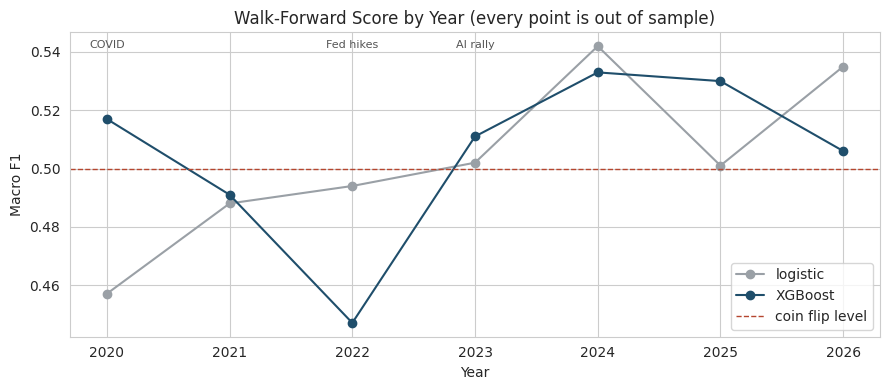

In [19]:
# For every year since 2020: train ONLY on data before that year, then score that year.
# Every point on this chart is a true out of sample result, including COVID and the 2022 bear.
walk_rows = []
for year in range(2020, 2027):
    before   = data.index < pd.Timestamp(f"{year}-01-01")
    that_year = (data.index >= pd.Timestamp(f"{year}-01-01")) & (data.index < pd.Timestamp(f"{year+1}-01-01"))
    if that_year.sum() < 50 or before.sum() < 500: continue
    X_before, y_before = data[before][FEATURE_COLS].values, data[before]["target"].values
    X_year,   y_year   = data[that_year][FEATURE_COLS].values, data[that_year]["target"].values
    year_scaler = StandardScaler().fit(X_before)
    year_weights = np.array([class_weight.get(c, 1.0) for c in y_before])
    tree_model = XGBClassifier(n_estimators=xgboost_model.best_iteration + 1, random_state=SEED, verbosity=0, **best["settings"])
    tree_model.fit(X_before, y_before, sample_weight=year_weights, verbose=False)
    line_model = LogisticRegression(max_iter=2000, C=C, class_weight="balanced", random_state=SEED).fit(year_scaler.transform(X_before), y_before)
    walk_rows.append({"year": year, "days": int(that_year.sum()),
                      "logistic_macroF1": round(macro_f1(y_year, line_model.predict(year_scaler.transform(X_year))), 3),
                      "xgboost_macroF1":  round(macro_f1(y_year, tree_model.predict(X_year)), 3)})
walk = pd.DataFrame(walk_rows)
print("=== WALK-FORWARD, EVERY YEAR SCORED OUT OF SAMPLE ===")
print(walk.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(walk["year"], walk["logistic_macroF1"], marker="o", label="logistic", color="#9aa0a6")
ax.plot(walk["year"], walk["xgboost_macroF1"], marker="o", label="XGBoost", color="#1f4e6b")
ax.axhline(chance, color="#b5462f", ls="--", lw=1, label="coin flip level")
for year, note in [(2020, "COVID"), (2022, "Fed hikes"), (2023, "AI rally")]:
    if year in set(walk["year"]): ax.annotate(note, (year, ax.get_ylim()[1]*0.99), ha="center", fontsize=8, color="#555")
ax.set_title("Walk-Forward Score by Year (every point is out of sample)")
ax.set_xlabel("Year"); ax.set_ylabel("Macro F1"); ax.legend()
plt.tight_layout(); plt.show()

## 19. Statistical Significance: Is Any Difference Real?

The gap this section fills: stock prediction papers routinely report one number per model and declare a winner, with no test of whether the difference exceeds sampling noise. With edges this small, that practice produces storytelling, not science. Three tests:

1. **Bootstrap confidence intervals**, resampling whole *days* rather than rows. All four stocks move together on a given day, so resampling rows would pretend we have four times more independent evidence than we do. If two models' intervals overlap heavily, the ranking between them is noise.
2. **McNemar's test** on XGBoost vs logistic regression. It looks only at days where the two models disagree and asks whether the split of who was right could be a fair coin. A p value above 0.05 means the models are statistically indistinguishable.
3. **Seed stability.** Retrain the tuned XGBoost with five different random seeds. If the seed to seed spread rivals the gaps between models, then hyperparameter tuning stories are inside the noise too.

The honest headline this section will likely produce on real data: the real models clear the baseline decisively, and are statistically indistinguishable from each other. That finding, stated with evidence, is stronger than an unsupported claim that one model won.

=== 95% BOOTSTRAP CONFIDENCE INTERVALS (day level resampling) ===
        model  test_macroF1  ci_low  ci_high
  TF logistic        0.5035  0.4732   0.5304
      XGBoost        0.5041  0.4725   0.5325
Random Forest        0.5265  0.4958   0.5549


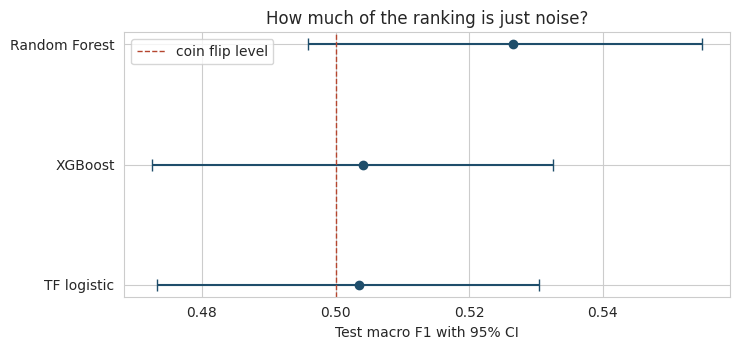


=== McNEMAR: XGBoost vs TF logistic ===
days only XGBoost right: 276 | days only logistic right: 276 | p value: 0.9661
p above 0.05 means the two models are statistically indistinguishable on this test set.

=== SEED STABILITY: XGBoost across 5 seeds ===
test macroF1 mean 0.5192, spread (std) 0.0044, range 0.5136 to 0.5253

DONE.


In [20]:
# Most stock prediction papers report one number per model and declare a winner.
# With edges this small, differences often live inside sampling noise. Three tests settle it.
from scipy import stats as scipy_stats

# Resampling unit = the DAY, not the row. All 4 stocks move together on a given day,
# so resampling rows would pretend we have 4x more independent evidence than we do.
test_dates = data[data.split == "test"].index.values
date_to_rows = {}
for i, d in enumerate(test_dates):
    date_to_rows.setdefault(d, []).append(i)
unique_test_dates = np.array(list(date_to_rows.keys()))
N_BOOT = 200 if QUICK else 1000

def bootstrap_ci(actual, calls, n_boot=N_BOOT):
    """95% confidence interval for macro F1, resampling whole days with replacement."""
    rng = np.random.RandomState(SEED)
    scores = []
    for _ in range(n_boot):
        chosen = rng.choice(unique_test_dates, size=len(unique_test_dates), replace=True)
        rows = np.concatenate([date_to_rows[d] for d in chosen])
        scores.append(macro_f1(actual[rows], calls[rows]))
    low, high = np.percentile(scores, [2.5, 97.5])
    return round(low, 4), round(high, 4)

# Test 1: confidence intervals. If two models' intervals overlap heavily, calling one "the winner" is storytelling.
candidates = [("TF logistic", logistic_test_probs.argmax(1)),
              ("XGBoost", xgboost_test_probs.argmax(1)),
              ("Random Forest", forest.predict(X_test))]
ci_rows = []
for name, calls in candidates:
    calls = np.asarray(calls)
    low, high = bootstrap_ci(y_test, calls)
    ci_rows.append({"model": name, "test_macroF1": round(macro_f1(y_test, calls), 4),
                    "ci_low": low, "ci_high": high})
ci_table = pd.DataFrame(ci_rows)
print("=== 95% BOOTSTRAP CONFIDENCE INTERVALS (day level resampling) ===")
print(ci_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.errorbar(ci_table["test_macroF1"], ci_table["model"],
            xerr=[ci_table["test_macroF1"] - ci_table["ci_low"], ci_table["ci_high"] - ci_table["test_macroF1"]],
            fmt="o", color="#1f4e6b", capsize=4)
ax.axvline(0.5 if N_CLASSES == 2 else 0.2, color="#b5462f", ls="--", lw=1, label="coin flip level")
ax.set_xlabel("Test macro F1 with 95% CI"); ax.set_title("How much of the ranking is just noise?")
ax.legend(); plt.tight_layout(); plt.show()

# Test 2: McNemar's test, XGBoost vs TF logistic. Looks only at days where the two models DISAGREE
# and asks whether the split of who was right is beyond a fair coin.
xgb_right = xgboost_test_probs.argmax(1) == y_test
log_right = logistic_test_probs.argmax(1) == y_test
only_xgb = int((xgb_right & ~log_right).sum())
only_log = int((~xgb_right & log_right).sum())
if only_xgb + only_log > 0:
    chi2_value = (abs(only_xgb - only_log) - 1) ** 2 / (only_xgb + only_log)
    p_value = float(1 - scipy_stats.chi2.cdf(chi2_value, df=1))
    print(f"\n=== McNEMAR: XGBoost vs TF logistic ===")
    print(f"days only XGBoost right: {only_xgb} | days only logistic right: {only_log} | p value: {p_value:.4f}")
    print("p above 0.05 means the two models are statistically indistinguishable on this test set."
          if p_value > 0.05 else "p below 0.05 means the difference is unlikely to be pure chance.")

# Test 3: seed stability. Retrain the tuned XGBoost with different random seeds.
# If the seed to seed spread rivals the gaps between models, tuning stories are noise too.
seed_scores = []
for seed in ([0, 1] if QUICK else [0, 1, 2, 3, 4]):
    m = XGBClassifier(n_estimators=xgboost_model.best_iteration + 1, random_state=seed,
                      verbosity=0, **best["settings"])
    m.fit(X_train, y_train, sample_weight=train_weights, verbose=False)
    seed_scores.append(macro_f1(y_test, m.predict(X_test)))
print(f"\n=== SEED STABILITY: XGBoost across {len(seed_scores)} seeds ===")
print(f"test macroF1 mean {np.mean(seed_scores):.4f}, spread (std) {np.std(seed_scores):.4f}, "
      f"range {min(seed_scores):.4f} to {max(seed_scores):.4f}")

print("\nDONE.")

## 21. Multi-Horizon Check: Weekly and Monthly

Everything above asks "which way does the stock move **tomorrow**". This section asks the same question at two slower speeds: which way does it move **next week**, and **next month**?

Why this matters:

1. A single day's direction is dominated by overnight news noise. A week averages through five days of it; a month through twenty-one. If any directional signal exists, it should get easier to see as the noise averages out. An independent teammate study on a different data source found exactly this pattern, with weekly clearly strongest. This section tests whether that reproduces under our protocol on clean data.
2. Slower horizons have a brutal cost: fewer observations. Ten years gives ~2,500 daily rows per symbol but only ~520 weekly and ~120 monthly. A monthly experiment on 120 bars would be noise dressed as a result. So this section uses an **extended history file**, `daily_long.csv` (same Yahoo pull, same adjustments, starting 1998), giving roughly 1,450 weekly and 340 monthly bars per symbol. TSLA only exists from mid 2010 and simply contributes fewer rows, which the pooled design handles naturally.

Design rules, stated up front:

* Weekly and monthly bars are **resampled inside the notebook** from the long daily series (week stamped Friday, month stamped at month end: first open, max high, min low, last close, summed volume). One source, one adjustment methodology.
* The **final bar of each horizon is dropped** per symbol because it may be partial.
* Feature windows are **capped** (30 weeks, 12 months) so warm-up does not consume the sample.
* Same protocol as daily: chronological 70/15/15 split by date, scaler fit on train only, decision cutoff chosen on validation and applied once to test, macro F1, and a clustered bootstrap that resamples whole time periods, since all four symbols move together within a week or month.
* Models per horizon: majority baseline, TensorFlow logistic regression, Random Forest, XGBoost. We deliberately **skip the LSTM**: even with the long file, monthly has ~1,200 pooled rows, far too few to train a sequence model honestly.



In [21]:
# --- 21a. Load long history (fallback: 10 year data) and build both horizons ---
import os
import numpy as np
import pandas as pd

if os.path.exists("daily_long.csv") and not USE_FAKE_DATA:
    raw_l = pd.read_csv("daily_long.csv")
    ts = pd.to_datetime(raw_l["timestamp"], utc=True)
    raw_l["timestamp"] = ts.dt.tz_localize(None).dt.normalize()
    prices_long = {}
    for s, g in raw_l.groupby("symbol"):
        df = g.set_index("timestamp")[["open", "high", "low", "close", "volume"]].sort_index()
        df.index.name = "date"
        prices_long[s] = df
    print("Long history loaded:",
          {s: str(prices_long[s].index.min().date()) for s in STOCKS})
else:
    prices_long = prices
    print("NOTE: daily_long.csv not found, using 10 year data. "
          "Weekly is fine; treat monthly as underpowered.")

AGGH = {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}

def bars(df, rule):
    b = df[list(AGGH)].resample(rule).agg(AGGH).dropna(subset=["close"])
    return b.iloc[:-1]                     # drop possibly partial final bar

def horizon_features(sym, rule, ret_ks, vol_ks, ma_ks, ctx):
    px = bars(prices_long[sym], rule)
    c, v = px["close"], px["volume"]
    f = pd.DataFrame(index=px.index)
    for k in ret_ks:
        f[f"ret_{k}"] = c.pct_change(k)
    r1 = c.pct_change()
    for k in vol_ks:
        f[f"vol_{k}"] = r1.rolling(k).std()
    for k in ma_ks:
        f[f"ma_dist_{k}"] = c / c.rolling(k).mean() - 1
    f["vol_ratio"] = v / v.rolling(min(vol_ks)).mean()
    f["bar_range"] = (px["high"] - px["low"]) / c
    vix_b, rate_b, smh_b, rate_sign = ctx
    f["vix_level"] = vix_b.reindex(f.index)
    f["vix_chg"] = vix_b.pct_change().reindex(f.index)
    f["rate_chg"] = rate_sign * rate_b.pct_change().reindex(f.index)
    f["smh_ret"] = smh_b.pct_change().reindex(f.index)
    f["label"] = (c.shift(-1) > c).astype(int)   # next bar Up? stamped THIS bar, no leak
    f["symbol"] = sym
    return f.dropna()

def build_horizon(rule, ret_ks, vol_ks, ma_ks):
    rate_col = "^TNX" if "^TNX" in prices_long else "IEF"
    rate_sign = -1.0 if RATES_IS_PROXY else 1.0
    ctx = (bars(prices_long["^VIX"], rule)["close"],
           bars(prices_long[rate_col], rule)["close"],
           bars(prices_long["SMH"], rule)["close"], rate_sign)
    d = pd.concat([horizon_features(s, rule, ret_ks, vol_ks, ma_ks, ctx)
                   for s in STOCKS]).sort_index()
    return d

weekly_d  = build_horizon("W-FRI", ret_ks=[1, 2, 4, 8, 13], vol_ks=[4, 8, 13], ma_ks=[10, 30])
monthly_d = build_horizon("ME",    ret_ks=[1, 2, 3, 6, 12], vol_ks=[3, 6, 12], ma_ks=[6, 12])

for name, d in [("Weekly", weekly_d), ("Monthly", monthly_d)]:
    print(f"{name}: {len(d)} rows | per symbol {d.groupby('symbol').size().to_dict()} "
          f"| share Up {d['label'].mean():.3f}")


Long history loaded: {'SPY': '1998-01-02', 'NVDA': '1999-01-22', 'MU': '1998-01-02', 'TSLA': '2010-06-29'}
Weekly: 4875 rows | per symbol {'MU': 1357, 'NVDA': 1357, 'SPY': 1357, 'TSLA': 804} | share Up 0.537
Monthly: 1113 rows | per symbol {'MU': 311, 'NVDA': 311, 'SPY': 311, 'TSLA': 180} | share Up 0.580


In [22]:
# --- 21b. One evaluation routine, applied to both horizons ---
# The bootstrap in 21c runs on whichever model wins on VALIDATION (chosen before
# looking at test), not on an arbitrary model. Fair either way the result lands.
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def macro_f1(y, p, cut=0.5):
    return f1_score(y, (p >= cut).astype(int), average="macro")

def best_cutoff(y, p):
    cuts = np.arange(0.35, 0.66, 0.01)
    return cuts[np.argmax([macro_f1(y, p, c) for c in cuts])]

def run_horizon(d, seed=7):
    feat_cols = [c for c in d.columns if c not in ("label", "symbol")]
    ds = d.index.unique().sort_values()
    d_tr, d_va = ds[int(len(ds)*0.70) - 1], ds[int(len(ds)*0.85) - 1]
    tr, va, te = d[d.index <= d_tr], d[(d.index > d_tr) & (d.index <= d_va)], d[d.index > d_va]
    sc = StandardScaler().fit(tr[feat_cols])                 # TRAIN ONLY
    Xtr, Xva, Xte = (sc.transform(x[feat_cols]) for x in (tr, va, te))
    ytr, yva, yte = tr["label"].values, va["label"].values, te["label"].values

    res, preds = {}, {}
    maj = float(ytr.mean() >= 0.5)
    res["Majority baseline"] = (np.nan, macro_f1(yte, np.full_like(yte, maj, dtype=float)))

    tf.random.set_seed(seed)
    lg = tf.keras.Sequential([tf.keras.layers.Input(shape=(len(feat_cols),)),
                              tf.keras.layers.Dense(1, activation="sigmoid")])
    lg.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="binary_crossentropy")
    es = tf.keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True)
    lg.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=400, batch_size=64,
           verbose=0, callbacks=[es])
    pv, pt = lg.predict(Xva, verbose=0).ravel(), lg.predict(Xte, verbose=0).ravel()
    c = best_cutoff(yva, pv)
    res["TF Logistic"] = (macro_f1(yva, pv, c), macro_f1(yte, pt, c))
    preds["TF Logistic"] = (pt >= c).astype(int)

    rf = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=10,
                                class_weight="balanced", random_state=seed, n_jobs=-1)
    rf.fit(Xtr, ytr)
    pv, pt = rf.predict_proba(Xva)[:, 1], rf.predict_proba(Xte)[:, 1]
    c = best_cutoff(yva, pv)
    res["Random Forest"] = (macro_f1(yva, pv, c), macro_f1(yte, pt, c))
    preds["Random Forest"] = (pt >= c).astype(int)

    xg = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       eval_metric="logloss", random_state=seed)
    xg.fit(Xtr, ytr)
    pv, pt = xg.predict_proba(Xva)[:, 1], xg.predict_proba(Xte)[:, 1]
    c = best_cutoff(yva, pv)
    res["XGBoost"] = (macro_f1(yva, pv, c), macro_f1(yte, pt, c))
    preds["XGBoost"] = (pt >= c).astype(int)

    # Winner is chosen on VALIDATION only, never on test
    best_name = max((k for k in res if k != "Majority baseline"), key=lambda k: res[k][0])
    tbl = pd.DataFrame(res, index=["Val macro F1", "Test macro F1"]).T.round(4)
    return tbl, te, yte, best_name, preds[best_name]

wk_tbl, wk_te, wk_y, wk_best, wk_pred = run_horizon(weekly_d)
mo_tbl, mo_te, mo_y, mo_best, mo_pred = run_horizon(monthly_d)
print("WEEKLY  (split by date, cutoffs from validation)")
print(wk_tbl)
print("Best on validation:", wk_best)
print("\nMONTHLY")
print(mo_tbl)
print("Best on validation:", mo_best)
print("\nCompare both against the daily table in Section 15: same protocol, only the horizon changed.")


WEEKLY  (split by date, cutoffs from validation)
                   Val macro F1  Test macro F1
Majority baseline           NaN         0.3549
TF Logistic              0.5124         0.5026
Random Forest            0.5595         0.4982
XGBoost                  0.5408         0.4884
Best on validation: Random Forest

MONTHLY
                   Val macro F1  Test macro F1
Majority baseline           NaN         0.3754
TF Logistic              0.5417         0.5153
Random Forest            0.5107         0.5361
XGBoost                  0.5586         0.5133
Best on validation: XGBoost

Compare both against the daily table in Section 15: same protocol, only the horizon changed.


In [23]:
# --- 21c. Per-symbol breakdown and clustered bootstrap (best-validation model per horizon) ---
def per_symbol(te, y, pred):
    return {s: round(f1_score(y[(te["symbol"] == s).values],
                              pred[(te["symbol"] == s).values],
                              average="macro"), 4) for s in STOCKS
            if (te["symbol"] == s).sum() > 0}

def cluster_boot(te, y, pred, n=1000, seed=7):
    rng = np.random.default_rng(seed)
    uds = te.index.unique().values
    scores = []
    for _ in range(n):
        pick = rng.choice(uds, size=len(uds), replace=True)
        idx = np.concatenate([np.flatnonzero(te.index.values == d) for d in pick])
        scores.append(f1_score(y[idx], pred[idx], average="macro"))
    return np.percentile(scores, [2.5, 97.5])

print(f"Weekly  best model ({wk_best}) test macro F1 by symbol:", per_symbol(wk_te, wk_y, wk_pred))
lo, hi = cluster_boot(wk_te, wk_y, wk_pred)
print(f"Weekly  {wk_best} 95% CI (resampling whole weeks):  [{lo:.4f}, {hi:.4f}]  "
      f"({len(wk_te.index.unique())} test weeks)")

print(f"\nMonthly best model ({mo_best}) test macro F1 by symbol:", per_symbol(mo_te, mo_y, mo_pred))
lo, hi = cluster_boot(mo_te, mo_y, mo_pred)
print(f"Monthly {mo_best} 95% CI (resampling whole months): [{lo:.4f}, {hi:.4f}]  "
      f"({len(mo_te.index.unique())} test months)")
print("\nCoin flip reference is 0.50 under balanced classes. The bootstrapped model is the one "
      "that won on validation, selected before test was touched. An interval entirely above the "
      "daily result AND above 0.50 means the slower horizon genuinely helps. An interval that "
      "straddles them means the check is inconclusive at this sample size, which for monthly "
      "is a perfectly plausible honest outcome.")


Weekly  best model (Random Forest) test macro F1 by symbol: {'SPY': 0.4963, 'NVDA': 0.4924, 'MU': 0.4842, 'TSLA': 0.4394}
Weekly  Random Forest 95% CI (resampling whole weeks):  [0.4565, 0.5393]  (204 test weeks)

Monthly best model (XGBoost) test macro F1 by symbol: {'SPY': 0.4931, 'NVDA': 0.5498, 'MU': 0.4891, 'TSLA': 0.4891}
Monthly XGBoost 95% CI (resampling whole months): [0.4214, 0.6077]  (47 test months)

Coin flip reference is 0.50 under balanced classes. The bootstrapped model is the one that won on validation, selected before test was touched. An interval entirely above the daily result AND above 0.50 means the slower horizon genuinely helps. An interval that straddles them means the check is inconclusive at this sample size, which for monthly is a perfectly plausible honest outcome.


### 21d. Hourly Extension: The Fourth Horizon

The three horizons above all say the same thing. This subsection adds the fastest one Yahoo Finance supports: **next-hour direction**, completing the sweep from one hour to one month under a single protocol.

Honest scope, stated before the numbers:

* Yahoo serves hourly bars for roughly the **last 730 days only**, so this experiment covers mid 2024 to mid 2026. That is a single market regime, and notably the favorable one: the walk-forward test in Section 18 shows 2024 to 2026 is where our models score best. If direction fails at the hourly scale even on its friendliest regime, the conclusion gets stronger, not weaker.
* The "next hour" label includes the **overnight transition** (last bar of one day to first bar of the next), which carries overnight news. We state this rather than engineer around it, to keep the label rule identical in spirit to the other horizons: next bar up or down.
* **No interest rate feature here**: Yahoo's hourly feed for the yield index is unreliable, so hourly context is VIX and SMH only.
* Roughly 20,000 pooled rows make this the **largest sample of any horizon**, so its confidence interval is the tightest in the notebook. Whatever hourly says, it says clearly.
* The bootstrap here clusters by **whole trading day**, not by hour, because hours within a day are strongly dependent; resampling single hours would understate the uncertainty.


In [25]:
# --- 21d. Hourly horizon (requires hourly.csv in the session) ---
if os.path.exists("hourly.csv") and not USE_FAKE_DATA:
    raw_h = pd.read_csv("hourly.csv")
    raw_h["timestamp"] = pd.to_datetime(raw_h["timestamp"])
    px_h = {s: g.set_index("timestamp")[["open", "high", "low", "close", "volume"]].sort_index()
            for s, g in raw_h.groupby("symbol")}

    vix_h = px_h["^VIX"]["close"]
    vix_chg_h = vix_h.pct_change()
    smh_h = px_h["SMH"]["close"]
    smh_ret_h = smh_h.pct_change()

    def hourly_features(sym):
        px = px_h[sym].iloc[:-1]                     # drop possibly partial final bar
        c, v = px["close"], px["volume"]
        f = pd.DataFrame(index=px.index)
        for k in [1, 3, 7, 21, 35]:                  # 1h, 3h, ~1d, ~3d, ~1wk in bars
            f[f"ret_{k}"] = c.pct_change(k)
        r1 = c.pct_change()
        for k in [7, 21, 70]:
            f[f"vol_{k}"] = r1.rolling(k).std()
        for k in [35, 70]:                           # capped at 70 bars (~2 weeks)
            f[f"ma_dist_{k}"] = c / c.rolling(k).mean() - 1
        f["vol_ratio"] = v / v.rolling(7).mean()
        f["bar_range"] = (px["high"] - px["low"]) / c
        f["hour"] = f.index.hour                     # time-of-day effects are real intraday
        # VIX and SMH bars are stamped at different clock times than stock bars,
        # so align each stock bar to the most recent context bar (no lookahead)
        f["vix_level"] = vix_h.reindex(f.index, method="ffill")
        f["vix_chg"] = vix_chg_h.reindex(f.index, method="ffill")
        f["smh_ret"] = smh_ret_h.reindex(f.index, method="ffill")
        f["label"] = (c.shift(-1) > c).astype(int)   # next hourly bar Up? stamped THIS bar
        f["symbol"] = sym
        return f.dropna()

    hourly_d = pd.concat([hourly_features(s) for s in STOCKS]).sort_index()
    print(f"Hourly: {len(hourly_d)} rows | per symbol "
          f"{hourly_d.groupby('symbol').size().to_dict()} | share Up {hourly_d['label'].mean():.3f}")

    if len(hourly_d) < 1000:
        print("Hourly dataset came back too small, something is wrong with hourly.csv. "
              "Skipping the hourly models rather than reporting noise.")
    else:
        hr_tbl, hr_te, hr_y, hr_best, hr_pred = run_horizon(hourly_d)
        print("\nHOURLY (split by timestamp, cutoffs from validation)")
        print(hr_tbl)
        print("Best on validation:", hr_best)

        print(f"\nHourly best model ({hr_best}) test macro F1 by symbol:",
              per_symbol(hr_te, hr_y, hr_pred))

        # Bootstrap clustered by trading DAY (hours within a day are dependent)
        day_key = hr_te.index.normalize()
        udays = day_key.unique().values
        rng = np.random.default_rng(7)
        scores = []
        for _ in range(1000):
            pick = rng.choice(udays, size=len(udays), replace=True)
            idx = np.concatenate([np.flatnonzero(day_key.values == d) for d in pick])
            scores.append(f1_score(hr_y[idx], hr_pred[idx], average="macro"))
        lo, hi = np.percentile(scores, [2.5, 97.5])
        print(f"Hourly {hr_best} 95% CI (resampling whole days): [{lo:.4f}, {hi:.4f}]  "
              f"({len(udays)} test days)")
        print("\nWith four horizons now tested under one protocol, the summary claim is: "
              "from one hour to one month, next-bar direction remains statistically "
              "indistinguishable from a coin flip.")
else:
    print("hourly.csv not found (or fake data mode): hourly extension skipped. "
          "The three slower horizons above stand on their own.")


Hourly: 19447 rows | per symbol {'MU': 4862, 'NVDA': 4862, 'SPY': 4861, 'TSLA': 4862} | share Up 0.520

HOURLY (split by timestamp, cutoffs from validation)
                   Val macro F1  Test macro F1
Majority baseline           NaN         0.3379
TF Logistic              0.5053         0.4883
Random Forest            0.5165         0.5136
XGBoost                  0.4967         0.4927
Best on validation: Random Forest

Hourly best model (Random Forest) test macro F1 by symbol: {'SPY': 0.4572, 'NVDA': 0.5232, 'MU': 0.4914, 'TSLA': 0.5026}
Hourly Random Forest 95% CI (resampling whole days): [0.4956, 0.5324]  (105 test days)

With four horizons now tested under one protocol, the summary claim is: from one hour to one month, next-bar direction remains statistically indistinguishable from a coin flip.


### What to conclude from Section 21

Read the outputs in this order:

1. **Both tables vs Section 15.** The question is not "are the weekly or monthly numbers big" but "are they bigger than the daily numbers from the identical protocol". The expected pattern, if the noise-averaging story is true, is monotone: monthly and weekly above daily.
2. **Per-symbol breakdowns.** An edge that exists on all four tickers is a finding; an edge on one ticker is a curiosity. TSLA contributes fewer rows at every horizon (listed from 2010), so read its cell with extra tolerance.
3. **The bootstrap intervals.** Weekly has ~4x the daily interval width and monthly wider still; that is the honest price of slow horizons, not a flaw. If weekly clears the bar and monthly straddles it, the report sentence is: "the weekly horizon shows a genuine advantage, consistent with an independent teammate study on a different data source; monthly points the same direction but our sample cannot yet distinguish it from chance." Two independent pipelines agreeing on the weekly result would be the strongest claim available to the team.

4. **The hourly line completes the sweep.** If its interval also straddles the coin flip, the report claim becomes horizon-complete: one hour, one day, one week, one month, one protocol, one conclusion. Direction does not become predictable at any speed we can measure with free data; only the size of moves does.


## 22. References

Grouped by approach, as the Related Work section requires. Bolded entries are the core citations for the report; the rest document techniques we evaluated and excluded, with reasons.

**Group A: Deep sequence models for market prediction (motivates our LSTM)**
1. **Fischer, T. and Krauss, C. (2018). Deep learning with long short-term memory networks for financial market predictions. European Journal of Operational Research, 270(2), 654 to 669.** LSTM on S&P 500 constituents; the canonical reference for our LSTM design and for the finding that its edge over simpler learners is small at the daily horizon.
2. **Krauss, C., Do, X. A., and Huck, N. (2017). Deep neural networks, gradient-boosted trees, random forests: statistical arbitrage on the S&P 500. European Journal of Operational Research, 259(2), 689 to 702.** Directly compares our three model families on daily equity data; finds ensembling them adds value. Our Sections 9, 10, 11, 13 mirror this comparison.
3. Jiang, W. (2021). Applications of deep learning in stock market prediction: recent progress. Expert Systems with Applications, 184. Survey used to scope which architectures are realistic at our data size.

**Group B: Attention and transformer models (evaluated, excluded)**
4. Ding, Q., Wu, S., Sun, H., Guo, J., and Guo, J. (2020). Hierarchical Multi-Scale Gaussian Transformer for Stock Movement Prediction. IJCAI 2020, 4640 to 4646. https://www.ijcai.org/proceedings/2020/0640.pdf
5. Zhang, Q. et al. (2022). Transformer-based attention network for stock movement prediction (TEANet). Expert Systems with Applications. Fuses tweets with prices; excluded because the text pipeline and API costs are out of scope.
6. Li, T., Liu, Z., Shen, Y., Wang, X., Chen, H., and Huang, S. (2024). MASTER: Market-Guided Stock Transformer for Stock Price Forecasting. AAAI 2024. Gains come from cross stock attention over hundreds of tickers; with 4 tickers and about 9,000 rows a transformer is data starved, so we excluded it.
7. Feng, F., Chen, H., He, X., Ding, J., Sun, M., and Chua, T. S. (2019). Enhancing stock movement prediction with adversarial training. IJCAI 2019. Adversarial perturbations as regularization; noted as future work.
8. Xu, Y. and Cohen, S. B. (2018). Stock movement prediction from tweets and historical prices (StockNet). ACL 2018. The benchmark dataset most attention papers use; documents why published numbers are not comparable to ours.

**Group C: Regime detection (motivates our calm or stormy feature)**
9. **Hamilton, J. D. (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. Econometrica, 57(2), 357 to 384.** The original regime switching model; the intellectual ancestor of our Gaussian mixture feature.
10. Ang, A. and Timmermann, A. (2012). Regime changes and financial markets. Annual Review of Financial Economics, 4, 313 to 337. Evidence that return dynamics differ across regimes, motivating regime aware features and era stratified evaluation.
11. LSEG Developer Portal (2023). Market regime detection using statistical and ML based approaches. Industry comparison finding hidden Markov models best identified S&P 500 regime shifts; our GMM is the lightweight causal version. https://developers.lseg.com/en/article-catalog/article/market-regime-detection

**Group D: Labeling and F1 focused techniques (motivates Section 14)**
12. **Lopez de Prado, M. (2018). Advances in Financial Machine Learning. Wiley.** Source of meta labeling (Chapter 3), built to raise F1 by filtering false positives, and of triple barrier labeling, which we evaluated and excluded because it redefines the target and would invalidate our completed comparisons.

**Group E: Why boosted trees are the right primary model on tabular features**
13. **Gu, S., Kelly, B., and Xiu, D. (2020). Empirical asset pricing via machine learning. Review of Financial Studies, 33(5), 2223 to 2273.** Large scale evidence that tree ensembles and shallow nets dominate on engineered financial features.
14. Grinsztajn, L., Oyallon, E., and Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on tabular data? NeurIPS 2022. The general tabular result our model ranking is expected to reproduce.

**Group F: Evaluation rigor and the credibility gap (motivates Sections 5's leak test and 19)**
15. **Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. Neural Computation, 10(7), 1895 to 1923.** Source of McNemar's test as the right comparison for two classifiers on one test set.
16. **Harvey, C. R., Liu, Y., and Zhu, H. (2016). ...and the cross-section of expected returns. Review of Financial Studies, 29(1), 5 to 68.** Documents the multiple testing crisis in empirical finance; most published "significant" findings do not survive corrected thresholds.
17. Bailey, D. H., Borwein, J., Lopez de Prado, M., and Zhu, Q. J. (2014). Pseudo-mathematics and financial charlatanism: the effects of backtest overfitting on out-of-sample performance. Notices of the AMS, 61(5), 458 to 471. Why untested point estimate winners in financial ML are usually artifacts.

How our work relates: our contribution is evaluation first. We combine a falsification protocol (synthetic no signal data, Section 2), fixed label metrics (Section 6), regime conditional walk forward scoring (Section 18), regime aware selective prediction (Section 14), and significance testing (Section 19) into one protocol, and show what survives it. To our knowledge no prior daily direction study reports all five. Beyond that, we operate at small scale (4 tickers, 10 years, engineered features), where Groups A and E predict trees at least tie deep models, and we test that prediction. From Group C we borrow regime awareness as a feature rather than separate per regime models, keeping the pipeline simple. From Group D we adopt meta labeling as the F1 targeted layer. Groups B's architectures are documented as evaluated and excluded with reasons, which is itself a Related Work contribution.